## ***Data Import***

In [318]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import plotly.express as px
import plotly.graph_objects as go

In [319]:
df = pd.read_csv('/content/9. Sales-Data-Analysis.csv')
display(df.head())

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin


In [320]:
Data_Info = pd.DataFrame({"Column": df.columns,"Non-Null Count": df.notnull().sum().values,"Dtype": df.dtypes.values})
display(Data_Info)

,Column,Non-Null Count,Dtype
0,Order ID,254,int64
1,Date,254,object
2,Product,254,object
3,Price,254,float64
4,Quantity,254,float64
5,Purchase Type,254,object
6,Payment Method,254,object
7,Manager,254,object
8,City,254,object


In [321]:
Total_Size = df.size
Total_Size_Data = pd.DataFrame({"Metric": ["Total Elements (Rows × Columns)"],"Value": [Total_Size]})
display(Total_Size_Data)

,Metric,Value
0,Total Elements (Rows × Columns),2286


In [322]:
Data_Type = pd.DataFrame({"Column": df.dtypes.index,"Dtype": df.dtypes.values})
display(Data_Type)

,Column,Dtype
0,Order ID,int64
1,Date,object
2,Product,object
3,Price,float64
4,Quantity,float64
5,Purchase Type,object
6,Payment Method,object
7,Manager,object
8,City,object


In [323]:
Data_Columns = pd.DataFrame({"Columns": df.columns.tolist()})
display(Data_Columns)

,Columns
0,Order ID
1,Date
2,Product
3,Price
4,Quantity
5,Purchase Type
6,Payment Method
7,Manager
8,City


,Column,Null Values
0,Order ID,0
1,Date,0
2,Product,0
3,Price,0
4,Quantity,0
5,Purchase Type,0
6,Payment Method,0
7,Manager,0
8,City,0


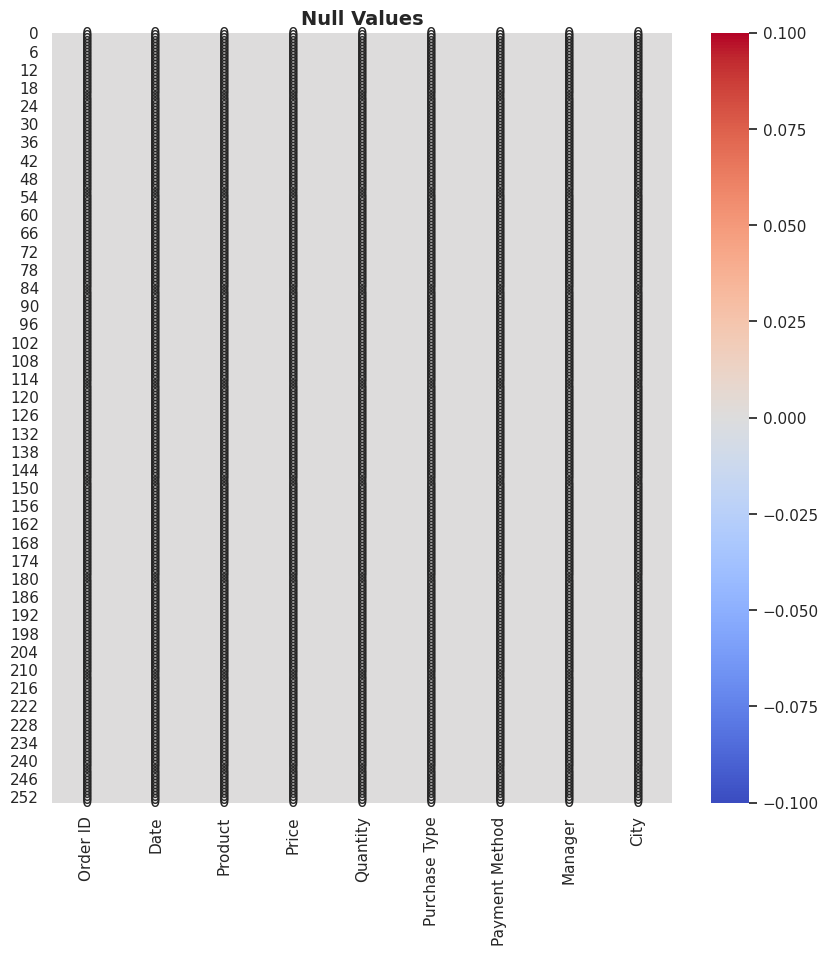

In [324]:
Null_Value = df.isnull().sum().sort_values(ascending=False)
Null_Value = pd.DataFrame({"Column": Null_Value.index,"Null Values": Null_Value.values})
display(Null_Value)

plt.figure(figsize=(10, 10))
sns.heatmap(df.isnull(), annot=True, cmap='coolwarm')
plt.title("Null Values", fontsize=14, weight='bold')
plt.show()

,Column,Unique Values
0,Order ID,254
1,Date,53
2,Quantity,29
3,Manager,14
4,Price,7
5,Product,5
6,City,5
7,Payment Method,3
8,Purchase Type,3


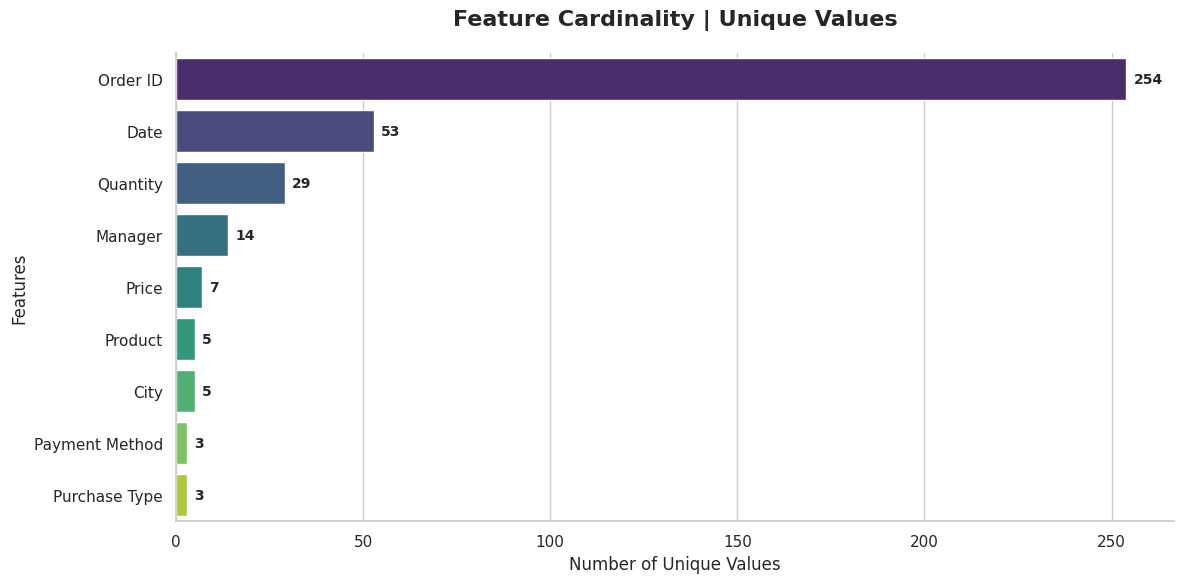

In [325]:
# Calculate and sort unique values
unique = (
    df.nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)

unique.columns = ["Column", "Unique Values"]

display(unique)

# Professional visualization
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(
    figsize=(12, max(6, len(unique) * 0.45))
)

sns.barplot(
    data=unique,
    x="Unique Values",
    y="Column",
    hue="Column",
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax
)

# Add exact values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

# Use logarithmic scale if counts vary substantially
positive = unique.loc[
    unique["Unique Values"] > 0, "Unique Values"
]

if not positive.empty and positive.max() / positive.min() > 100:
    ax.set_xscale("log")

ax.set_title(
    "Feature Cardinality | Unique Values",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Number of Unique Values", fontsize=12)
ax.set_ylabel("Features", fontsize=12)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [326]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

display(outliers)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
28,10482,13-11-2022,Fries,25.50,630.37,In-store,Credit Card,Joao Silva,Lisbon
29,10486,14-11-2022,Chicken Sandwiches,29.05,201.01,In-store,Credit Card,Joao Silva,Lisbon


## ***EDA***

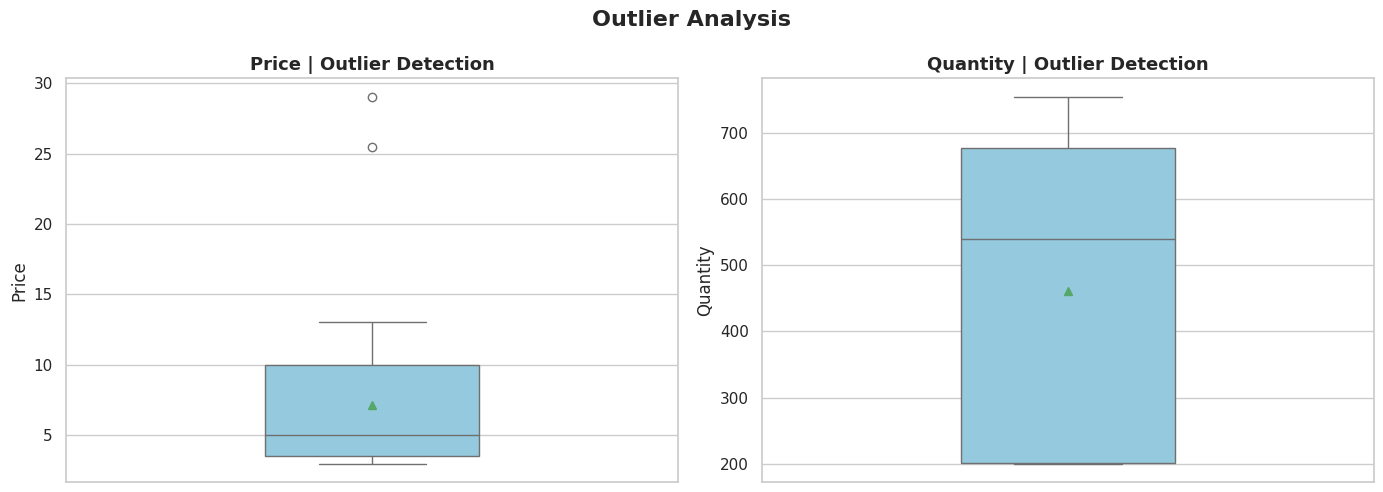

In [327]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["Price", "Quantity"]):
    sns.boxplot(
        data=df,
        y=col,
        color="skyblue",
        width=0.35,
        showmeans=True,
        ax=ax
    )
    ax.set_title(f"{col} | Outlier Detection",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel(col)

plt.suptitle(
    "Outlier Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

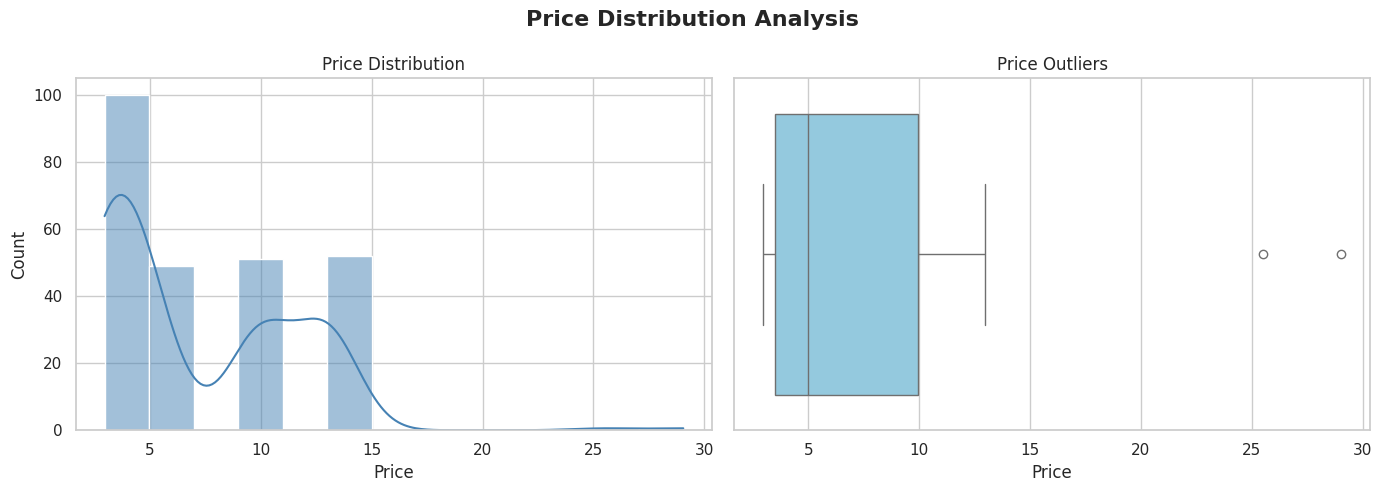

In [328]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="Price",
    kde=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Price Distribution")

sns.boxplot(
    data=df,
    x="Price",
    color="skyblue",
    ax=axes[1]
)

axes[1].set_title("Price Outliers")

plt.suptitle(
    "Price Distribution Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [329]:
# Create a working copy
sales = df.copy()

# Ensure numeric data types
sales["Price"] = pd.to_numeric(
    sales["Price"], errors="coerce"
)

sales["Quantity"] = pd.to_numeric(
    sales["Quantity"], errors="coerce"
)

# Calculate revenue
sales["Revenue"] = (
    sales["Price"] * sales["Quantity"]
)

display(sales.head())

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London,2000.0143
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid,2199.9920
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon,999.9960
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin,7400.0133
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin,2000.0495


In [330]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity",
        "Total Orders",
        "Average Order Revenue",
        "Total Products"
    ],
    "Value": [
        sales["Revenue"].sum(),
        sales["Quantity"].sum(),
        sales["Order ID"].nunique(),
        sales.groupby("Order ID")["Revenue"].sum().mean(),
        sales["Product"].nunique()
    ]
})

display(kpi.round(2))

,Metric,Value
0,Total Revenue,769515.86
1,Total Quantity,116995.31
2,Total Orders,254.00
3,Average Order Revenue,3029.59
4,Total Products,5.00


In [331]:
product_sales = (
    sales.groupby("Product", as_index=False)
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Average_Price=("Price", "mean"),
        Total_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
)

display(product_sales.round(2))

,Product,Total_Revenue,Total_Quantity,Average_Price,Total_Orders
1,Burgers,376999.81,29022.31,12.99,52
3,Fries,125674.29,32034.34,3.92,51
2,Chicken Sandwiches,114641.70,11135.92,10.32,52
0,Beverages,103200.26,34983.14,2.95,50
4,Sides & Other,48999.80,9819.60,4.99,49


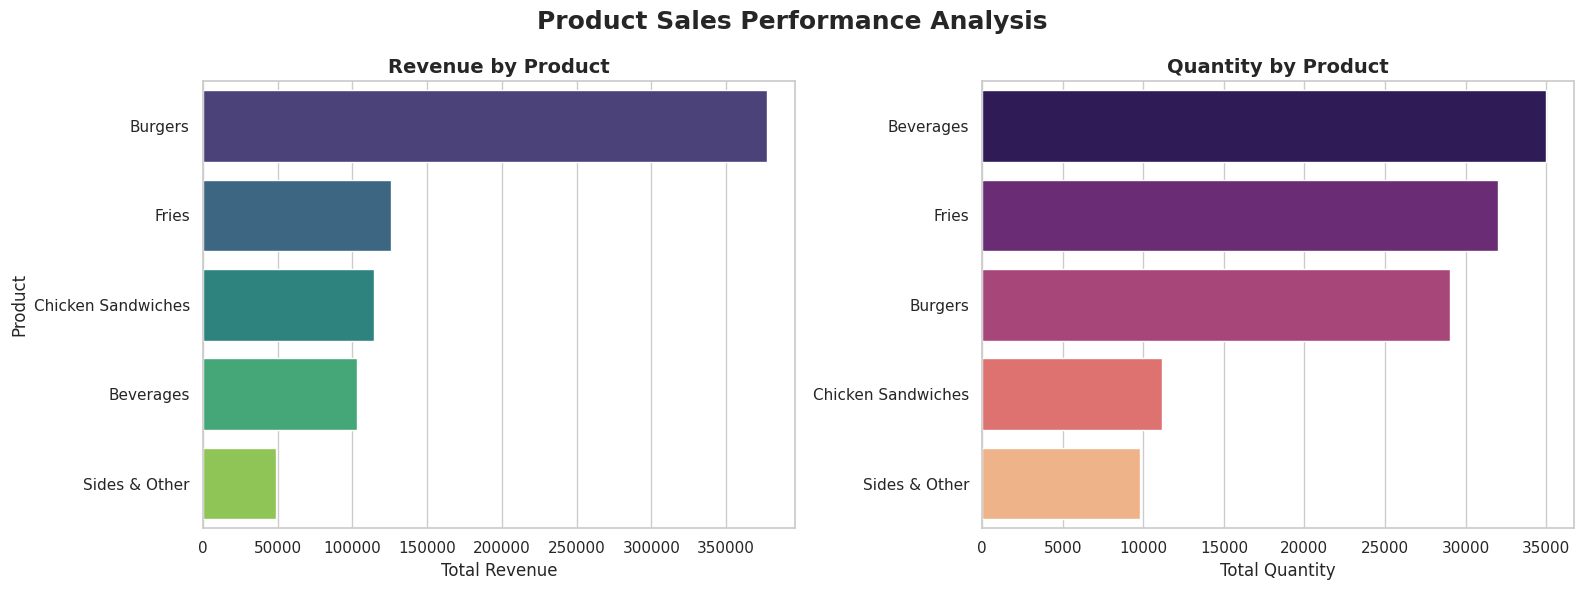

In [332]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6)
)

# Revenue by product
sns.barplot(
    data=product_sales,
    x="Total_Revenue",
    y="Product",
    hue="Product",
    palette="viridis",
    dodge=False,
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Revenue by Product",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Total Revenue")
axes[0].set_ylabel("Product")

# Quantity by product
quantity_sales = product_sales.sort_values(
    "Total_Quantity",
    ascending=False
)

sns.barplot(
    data=quantity_sales,
    x="Total_Quantity",
    y="Product",
    hue="Product",
    palette="magma",
    dodge=False,
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Quantity by Product",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Total Quantity")
axes[1].set_ylabel("")

plt.suptitle(
    "Product Sales Performance Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [333]:
top_revenue = product_sales.loc[
    product_sales["Total_Revenue"].idxmax()
]

top_quantity = product_sales.loc[
    product_sales["Total_Quantity"].idxmax()
]

insights = pd.DataFrame({
    "Business Insight": [
        "Highest Revenue Product",
        "Best-Selling Product by Quantity",
        "Highest Product Revenue",
        "Highest Quantity Sold"
    ],
    "Result": [
        top_revenue["Product"],
        top_quantity["Product"],
        round(top_revenue["Total_Revenue"], 2),
        round(top_quantity["Total_Quantity"], 2)
    ]
})

display(insights)

,Business Insight,Result
0,Highest Revenue Product,Burgers
1,Best-Selling Product by Quantity,Beverages
2,Highest Product Revenue,376999.81
3,Highest Quantity Sold,34983.14


In [334]:
# Convert date column
sales["Date"] = pd.to_datetime(
    sales["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Create time-based features
sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month
sales["Month_Name"] = sales["Date"].dt.strftime("%b")
sales["Day"] = sales["Date"].dt.day_name()

display(sales.head())

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Year,Month,Month_Name,Day
0,10452,2022-11-07,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London,2000.0143,2022,11,Nov,Monday
1,10453,2022-11-07,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid,2199.9920,2022,11,Nov,Monday
2,10454,2022-11-07,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon,999.9960,2022,11,Nov,Monday
3,10455,2022-11-08,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin,7400.0133,2022,11,Nov,Tuesday
4,10456,2022-11-08,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin,2000.0495,2022,11,Nov,Tuesday


,Date,Total_Revenue
0,2022-11-07,5200.0023
1,2022-11-08,12400.0731
2,2022-11-09,14200.0386
3,2022-11-10,13200.0426
4,2022-11-11,14400.0156


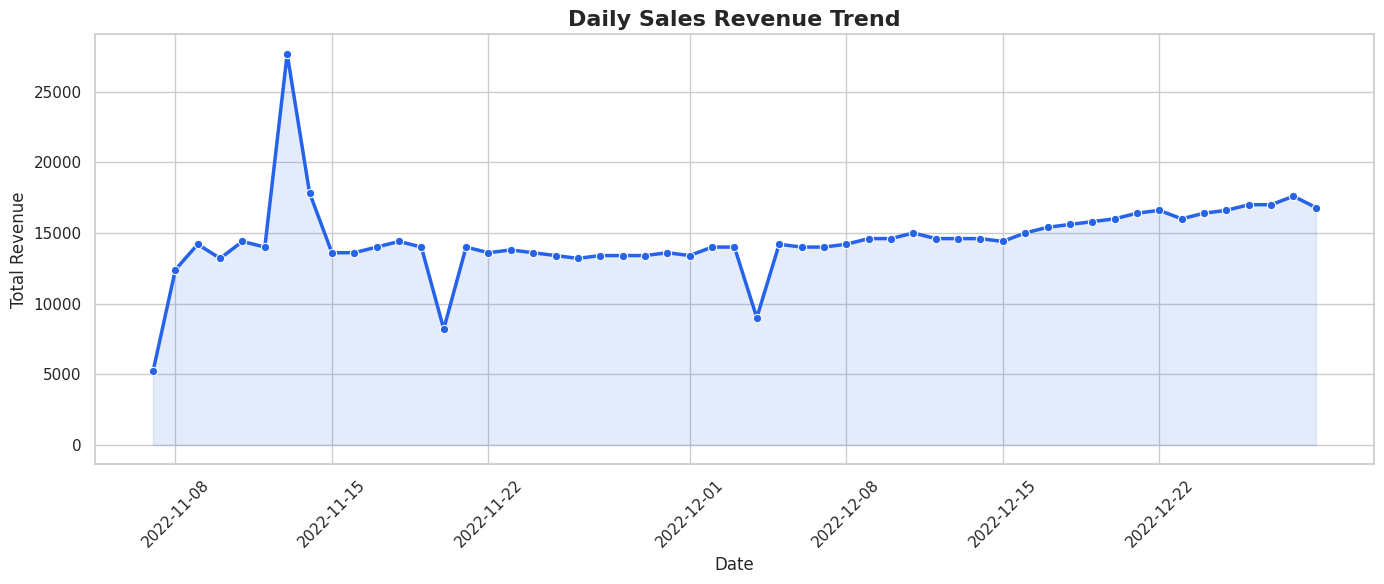

In [335]:
daily_sales = (
    sales.groupby("Date", as_index=False)
    .agg(Total_Revenue=("Revenue", "sum"))
    .sort_values("Date")
)

display(daily_sales.head())

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_sales,
    x="Date",
    y="Total_Revenue",
    marker="o",
    linewidth=2.5,
    color="#2563eb"
)

plt.fill_between(
    daily_sales["Date"],
    daily_sales["Total_Revenue"],
    alpha=0.12,
    color="#2563eb"
)

plt.title(
    "Daily Sales Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

,Date,Revenue
0,2022-11-01,332114.6584
1,2022-12-01,437401.2008


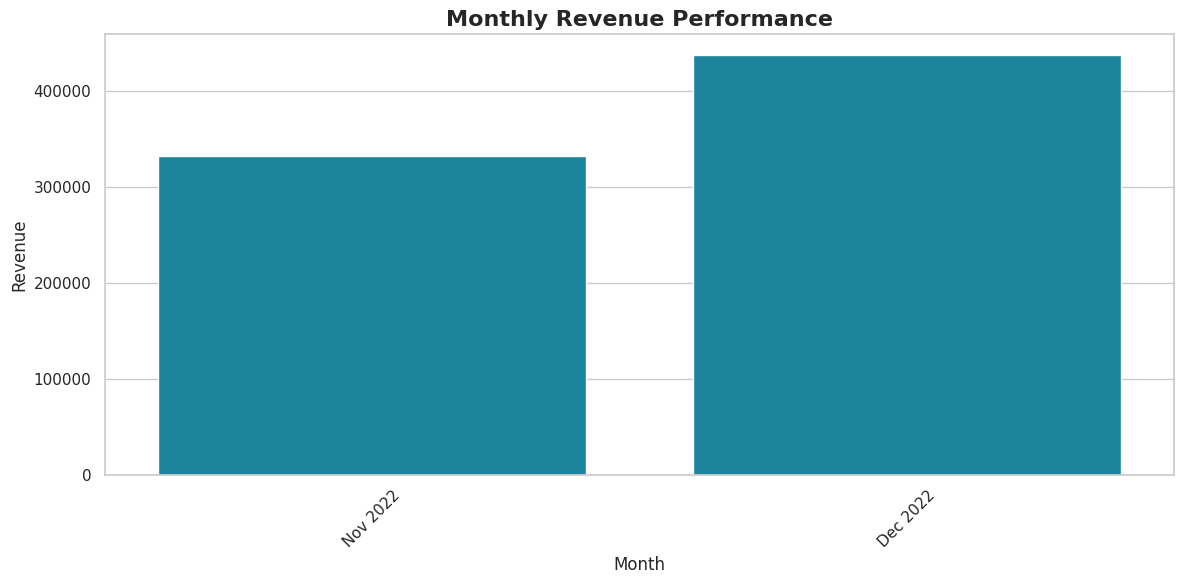

In [336]:
monthly_sales = (
    sales.groupby(
        sales["Date"].dt.to_period("M")
    )["Revenue"]
    .sum()
    .reset_index()
)

monthly_sales["Date"] = (
    monthly_sales["Date"].dt.to_timestamp()
)

display(monthly_sales)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_sales,
    x="Date",
    y="Revenue",
    color="#0891b2"
)

plt.title(
    "Monthly Revenue Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(
    ticks=range(len(monthly_sales)),
    labels=monthly_sales["Date"].dt.strftime("%b %Y"),
    rotation=45
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

,Day,Revenue
0,Monday,112039.5574
1,Tuesday,114600.3521
2,Wednesday,117800.2088
3,Thursday,116200.4728
4,Friday,101800.2809
5,Saturday,101600.3307
6,Sunday,105474.6565


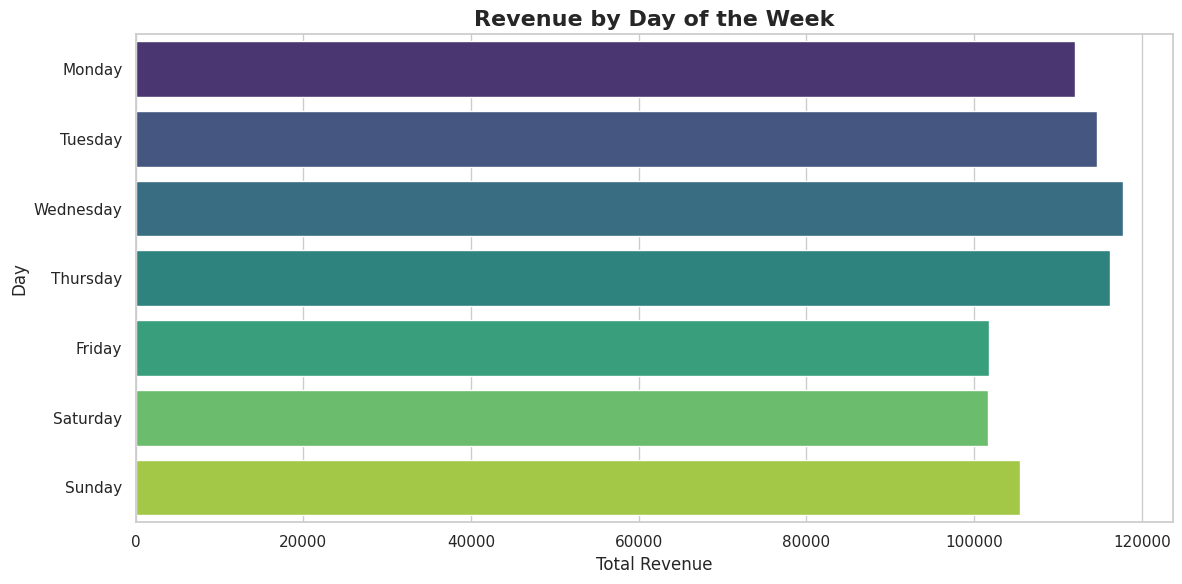

In [337]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_sales = (
    sales.groupby("Day")["Revenue"]
    .sum()
    .reindex(day_order)
    .reset_index()
)

display(weekday_sales)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=weekday_sales,
    x="Revenue",
    y="Day",
    hue="Day",
    palette="viridis",
    dodge=False,
    legend=False
)

plt.title(
    "Revenue by Day of the Week",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Revenue")
plt.ylabel("Day")

plt.tight_layout()
plt.show()

In [338]:
insights = pd.DataFrame({
    "Business Metric": [
        "Highest Revenue Day",
        "Lowest Revenue Day",
        "Peak Revenue Month",
        "Average Daily Revenue"
    ],
    "Result": [
        daily_sales.loc[
            daily_sales["Total_Revenue"].idxmax(), "Date"
        ].strftime("%d %B %Y"),

        daily_sales.loc[
            daily_sales["Total_Revenue"].idxmin(), "Date"
        ].strftime("%d %B %Y"),

        monthly_sales.loc[
            monthly_sales["Revenue"].idxmax(), "Date"
        ].strftime("%B %Y"),

        round(daily_sales["Total_Revenue"].mean(), 2)
    ]
})

display(insights)

,Business Metric,Result
0,Highest Revenue Day,13 November 2022
1,Lowest Revenue Day,07 November 2022
2,Peak Revenue Month,December 2022
3,Average Daily Revenue,14519.17


In [339]:
# Create a working copy
customer_sales = sales.copy()

# Clean categorical columns
columns = [
    "Purchase Type",
    "Payment Method",
    "City",
    "Manager"
]

for col in columns:
    customer_sales[col] = (
        customer_sales[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Verify categorical values
for col in columns:
    display(
        customer_sales[col]
        .value_counts(dropna=False)
        .to_frame(name="Count")
    )

,Count
Purchase Type,
Online,107
In-store,86
Drive-thru,61


,Count
Payment Method,
Credit Card,120
Cash,76
Gift Card,58


,Count
City,
London,75
Lisbon,75
Madrid,46
Berlin,30
Paris,28


,Count
Manager,
Tom Jackson,75
Joao Silva,75
Pablo Perez,46
Walter Muller,30
Remy Monet,28


In [340]:
purchase_analysis = (
    customer_sales
    .groupby("Purchase Type")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("Order ID", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

purchase_analysis["Average_Order_Value"] = (
    purchase_analysis["Total_Revenue"] /
    purchase_analysis["Total_Orders"]
)

purchase_analysis = purchase_analysis.sort_values(
    "Total_Revenue",
    ascending=False
)

display(purchase_analysis.round(2))

,Purchase Type,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value
2,Online,305201.39,107,48999.16,2852.35
1,In-store,285714.00,86,40229.09,3322.26
0,Drive-thru,178600.47,61,27767.06,2927.88


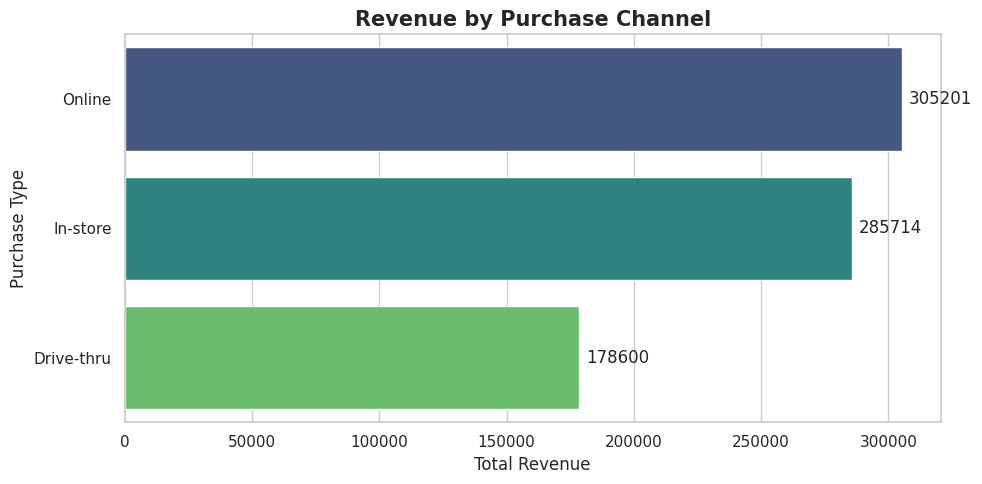

In [341]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=purchase_analysis,
    x="Total_Revenue",
    y="Purchase Type",
    hue="Purchase Type",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=5
    )

plt.title(
    "Revenue by Purchase Channel",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Total Revenue")
plt.ylabel("Purchase Type")
plt.tight_layout()
plt.show()

,Payment Method,Total_Revenue,Total_Orders
1,Credit Card,361715.03,120
0,Cash,239200.24,76
2,Gift Card,168600.60,58


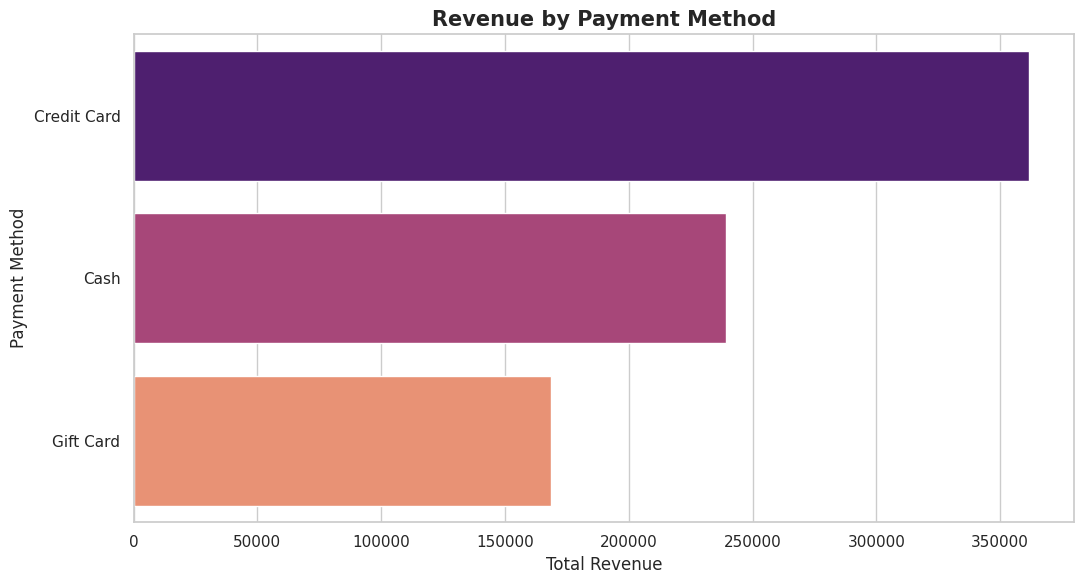

In [342]:
payment_analysis = (
    customer_sales
    .groupby("Payment Method")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("Order ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

display(payment_analysis.round(2))

plt.figure(figsize=(11, 6))

sns.barplot(
    data=payment_analysis,
    x="Total_Revenue",
    y="Payment Method",
    hue="Payment Method",
    palette="magma",
    legend=False
)

plt.title(
    "Revenue by Payment Method",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Total Revenue")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

,City,Total_Revenue,Total_Orders,Total_Quantity
1,Lisbon,241714.12,75,35752.84
2,London,211201.04,75,33535.34
3,Madrid,136200.27,46,20444.25
0,Berlin,100600.13,30,14771.35
4,Paris,79800.31,28,12491.53


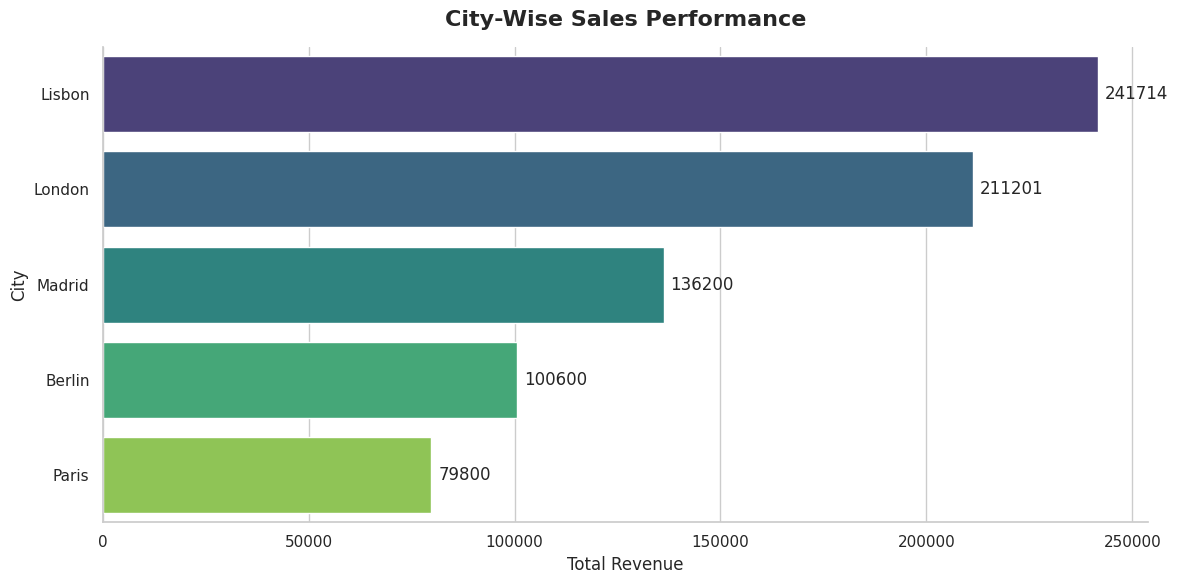

In [343]:
city_sales = (
    customer_sales
    .groupby("City")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("Order ID", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

display(city_sales.round(2))

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=city_sales,
    x="Total_Revenue",
    y="City",
    hue="City",
    palette="viridis",
    legend=False,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=5)

ax.set_title(
    "City-Wise Sales Performance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Total Revenue")
ax.set_ylabel("City")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Payment Method,Cash,Credit Card,Gift Card
Purchase Type,,,
Drive-thru,52600.17,90600.25,35400.05
In-store,144799.92,137914.07,3000.01
Online,41800.15,133200.70,130200.54


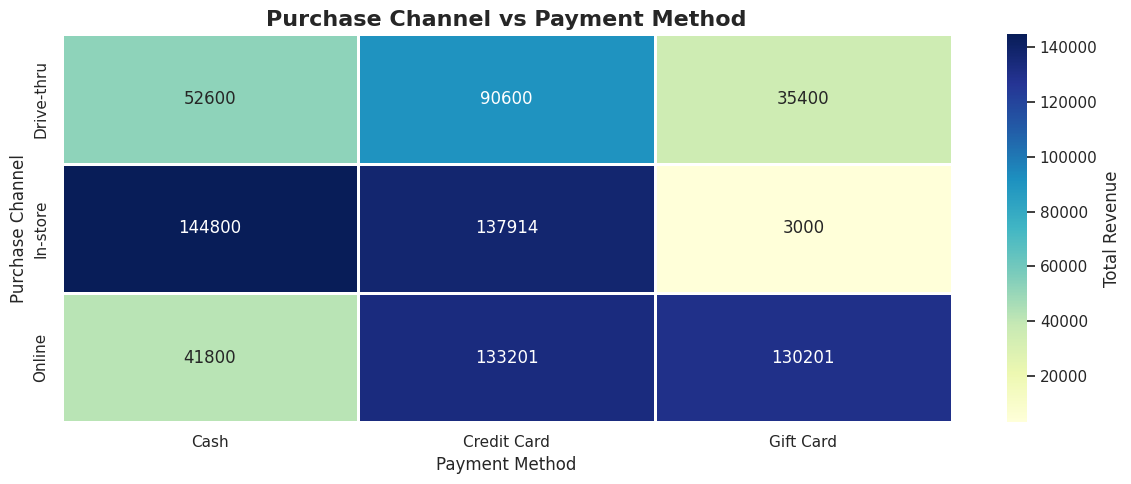

In [344]:
payment_heatmap = customer_sales.pivot_table(
    index="Purchase Type",
    columns="Payment Method",
    values="Revenue",
    aggfunc="sum",
    fill_value=0
)

display(payment_heatmap.round(2))

plt.figure(figsize=(12, 5))

sns.heatmap(
    payment_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.8,
    cbar_kws={"label": "Total Revenue"}
)

plt.title(
    "Purchase Channel vs Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Purchase Channel")
plt.tight_layout()
plt.show()

In [345]:
insights = pd.DataFrame({
    "Business Insight": [
        "Highest Revenue City",
        "Top Purchase Channel",
        "Most Revenue-Generating Payment Method",
        "Total Sales Revenue"
    ],
    "Result": [
        city_sales.iloc[0]["City"],
        purchase_analysis.iloc[0]["Purchase Type"],
        payment_analysis.iloc[0]["Payment Method"],
        round(customer_sales["Revenue"].sum(), 2)
    ]
})

display(insights)

,Business Insight,Result
0,Highest Revenue City,Lisbon
1,Top Purchase Channel,Online
2,Most Revenue-Generating Payment Method,Credit Card
3,Total Sales Revenue,769515.86


In [346]:
manager_sales = (
    customer_sales
    .groupby("Manager")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("Order ID", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Average_Price=("Price", "mean")
    )
    .reset_index()
)

manager_sales["Average_Order_Value"] = (
    manager_sales["Total_Revenue"] /
    manager_sales["Total_Orders"]
)

manager_sales["Revenue_Share_%"] = (
    manager_sales["Total_Revenue"] /
    manager_sales["Total_Revenue"].sum() * 100
)

manager_sales = manager_sales.sort_values(
    "Total_Revenue",
    ascending=False
)

display(manager_sales.round(2))

,Manager,Total_Revenue,Total_Orders,Total_Quantity,Average_Price,Average_Order_Value,Revenue_Share_%
0,Joao Silva,241714.12,75,35752.84,7.29,3222.85,31.41
3,Tom Jackson,211201.04,75,33535.34,6.95,2816.01,27.45
1,Pablo Perez,136200.27,46,20444.25,7.21,2960.88,17.70
4,Walter Muller,100600.13,30,14771.35,6.87,3353.34,13.07
2,Remy Monet,79800.31,28,12491.53,7.08,2850.01,10.37


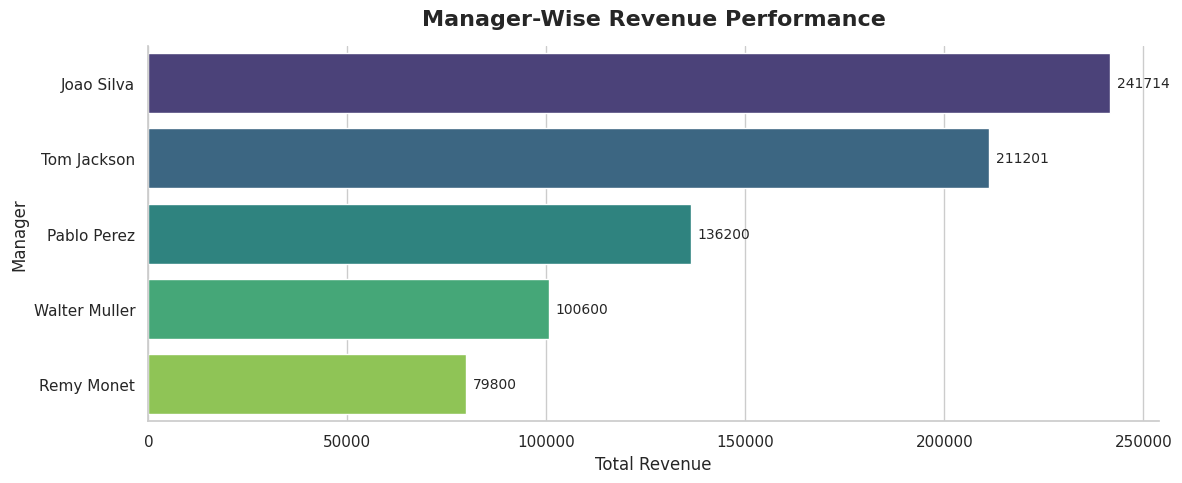

In [347]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(
    figsize=(12, max(5, len(manager_sales) * 0.6))
)

sns.barplot(
    data=manager_sales,
    x="Total_Revenue",
    y="Manager",
    hue="Manager",
    palette="viridis",
    legend=False,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=5,
        fontsize=10
    )

ax.set_title(
    "Manager-Wise Revenue Performance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Total Revenue")
ax.set_ylabel("Manager")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

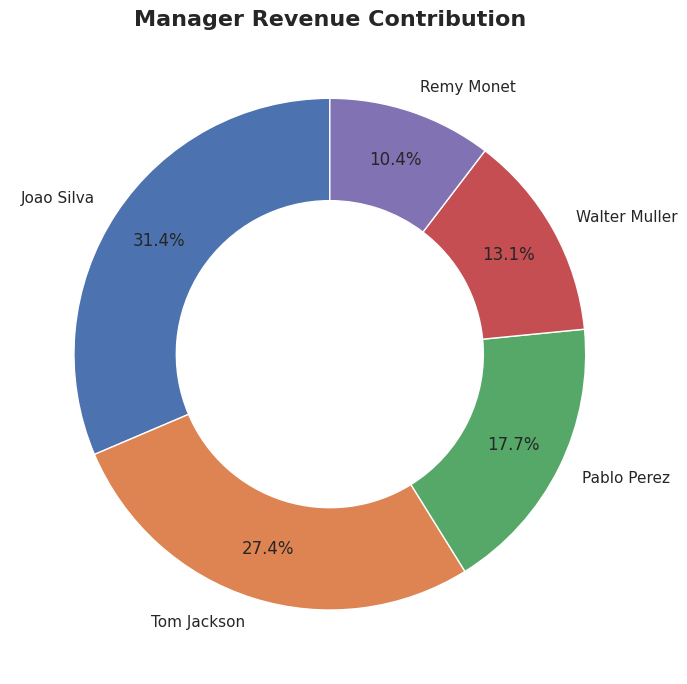

In [348]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.pie(
    manager_sales["Total_Revenue"],
    labels=manager_sales["Manager"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    wedgeprops={
        "width": 0.4,
        "edgecolor": "white"
    }
)

ax.set_title(
    "Manager Revenue Contribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

City,Berlin,Lisbon,London,Madrid,Paris
Manager,,,,,
Joao Silva,0.00,241714.12,0.00,0.00,0.00
Pablo Perez,0.00,0.00,0.00,136200.27,0.00
Remy Monet,0.00,0.00,0.00,0.00,79800.31
Tom Jackson,0.00,0.00,211201.04,0.00,0.00
Walter Muller,100600.13,0.00,0.00,0.00,0.00


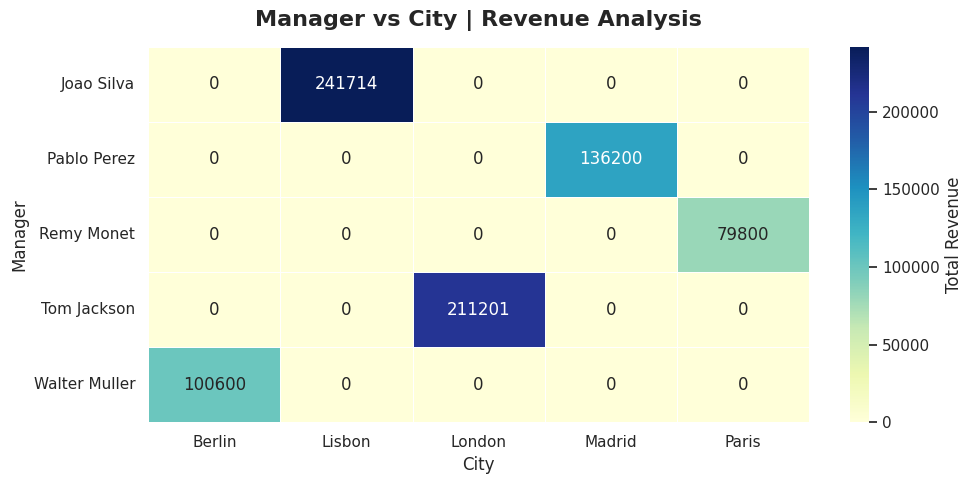

In [349]:
manager_city = customer_sales.pivot_table(
    index="Manager",
    columns="City",
    values="Revenue",
    aggfunc="sum",
    fill_value=0
)

display(manager_city.round(2))

plt.figure(
    figsize=(max(10, len(manager_city.columns) * 1.3),
             max(5, len(manager_city) * 0.6))
)

sns.heatmap(
    manager_city,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Total Revenue"}
)

plt.title(
    "Manager vs City | Revenue Analysis",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("City")
plt.ylabel("Manager")
plt.tight_layout()
plt.show()

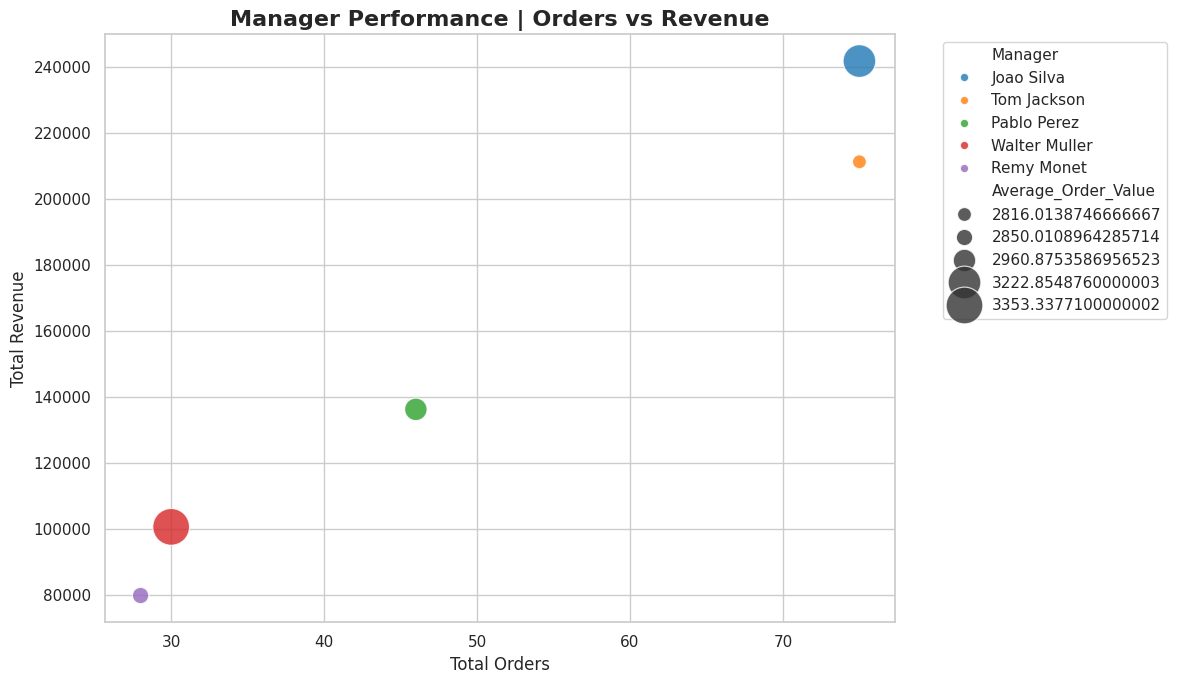

In [350]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=manager_sales,
    x="Total_Orders",
    y="Total_Revenue",
    size="Average_Order_Value",
    hue="Manager",
    sizes=(100, 700),
    alpha=0.8,
    palette="tab10"
)

plt.title(
    "Manager Performance | Orders vs Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Orders")
plt.ylabel("Total Revenue")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [351]:
insights = pd.DataFrame({
    "Business Metric": [
        "Highest Revenue Manager",
        "Highest Order Volume Manager",
        "Highest Average Order Value Manager",
        "Total Revenue",
        "Total Managers"
    ],
    "Result": [
        manager_sales.loc[
            manager_sales["Total_Revenue"].idxmax(),
            "Manager"
        ],
        manager_sales.loc[
            manager_sales["Total_Orders"].idxmax(),
            "Manager"
        ],
        manager_sales.loc[
            manager_sales["Average_Order_Value"].idxmax(),
            "Manager"
        ],
        round(manager_sales["Total_Revenue"].sum(), 2),
        manager_sales["Manager"].nunique()
    ]
})

display(insights)

,Business Metric,Result
0,Highest Revenue Manager,Joao Silva
1,Highest Order Volume Manager,Joao Silva
2,Highest Average Order Value Manager,Walter Muller
3,Total Revenue,769515.86
4,Total Managers,5


City,Berlin,Lisbon,London,Madrid,Paris
Product,,,,,
Beverages,12000.07,33600.03,28800.08,18400.06,10400.02
Burgers,53399.94,108799.82,101800.29,73599.78,39399.97
Chicken Sandwiches,16000.20,36639.96,32000.79,18000.45,12000.30
Fries,13199.95,47674.36,34599.93,17200.01,13000.04
Sides & Other,5999.98,14999.94,13999.94,8999.96,4999.98


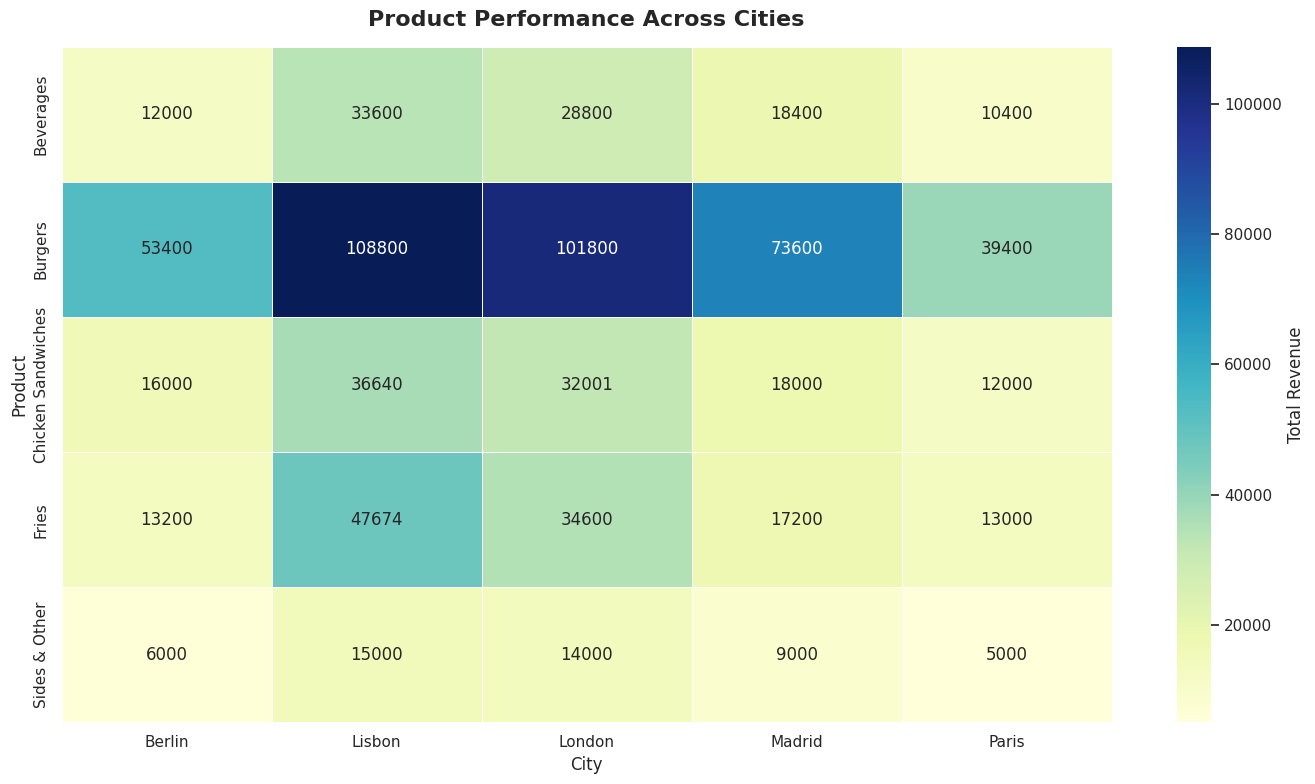

In [352]:
product_city = customer_sales.pivot_table(
    index="Product",
    columns="City",
    values="Revenue",
    aggfunc="sum",
    fill_value=0
)

display(product_city.round(2))

plt.figure(figsize=(14, 8))

sns.heatmap(
    product_city,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Total Revenue"}
)

plt.title(
    "Product Performance Across Cities",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("City")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [353]:
monthly_growth = (
    customer_sales
    .dropna(subset=["Date"])
    .groupby(
        customer_sales["Date"].dt.to_period("M")
    )["Revenue"]
    .sum()
    .reset_index()
)

monthly_growth.columns = ["Month", "Revenue"]

monthly_growth["MoM_Growth_%"] = (
    monthly_growth["Revenue"]
    .pct_change(fill_method=None) * 100
)

display(monthly_growth.round(2))

,Month,Revenue,MoM_Growth_%
0,2022-11,332114.66,NaN
1,2022-12,437401.20,31.7


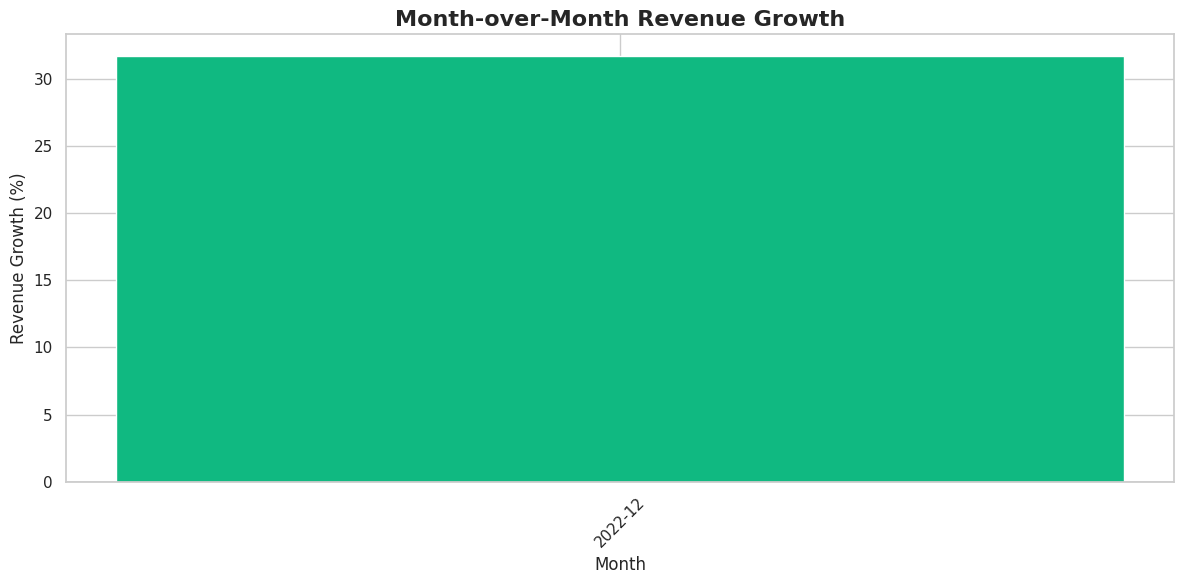

In [354]:
growth_plot = monthly_growth.dropna(
    subset=["MoM_Growth_%"]
).copy()

growth_plot["Month"] = (
    growth_plot["Month"].astype(str)
)

growth_plot["Color"] = growth_plot[
    "MoM_Growth_%"
].apply(
    lambda x: "#10b981" if x >= 0 else "#ef4444"
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    growth_plot["Month"],
    growth_plot["MoM_Growth_%"],
    color=growth_plot["Color"]
)

ax.axhline(0, color="gray", linewidth=1)

ax.set_title(
    "Month-over-Month Revenue Growth",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Revenue Growth (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Price,Quantity,Revenue
Price,1.000,-0.260,0.762
Quantity,-0.260,1.000,0.349
Revenue,0.762,0.349,1.000


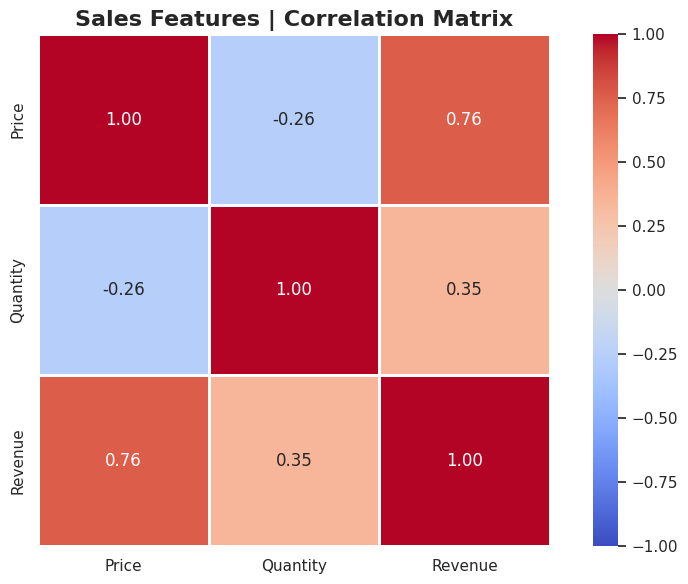

In [355]:
numeric_features = [
    "Price",
    "Quantity",
    "Revenue"
]

correlation = (
    customer_sales[numeric_features]
    .corr()
)

display(correlation.round(3))

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1
)

plt.title(
    "Sales Features | Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

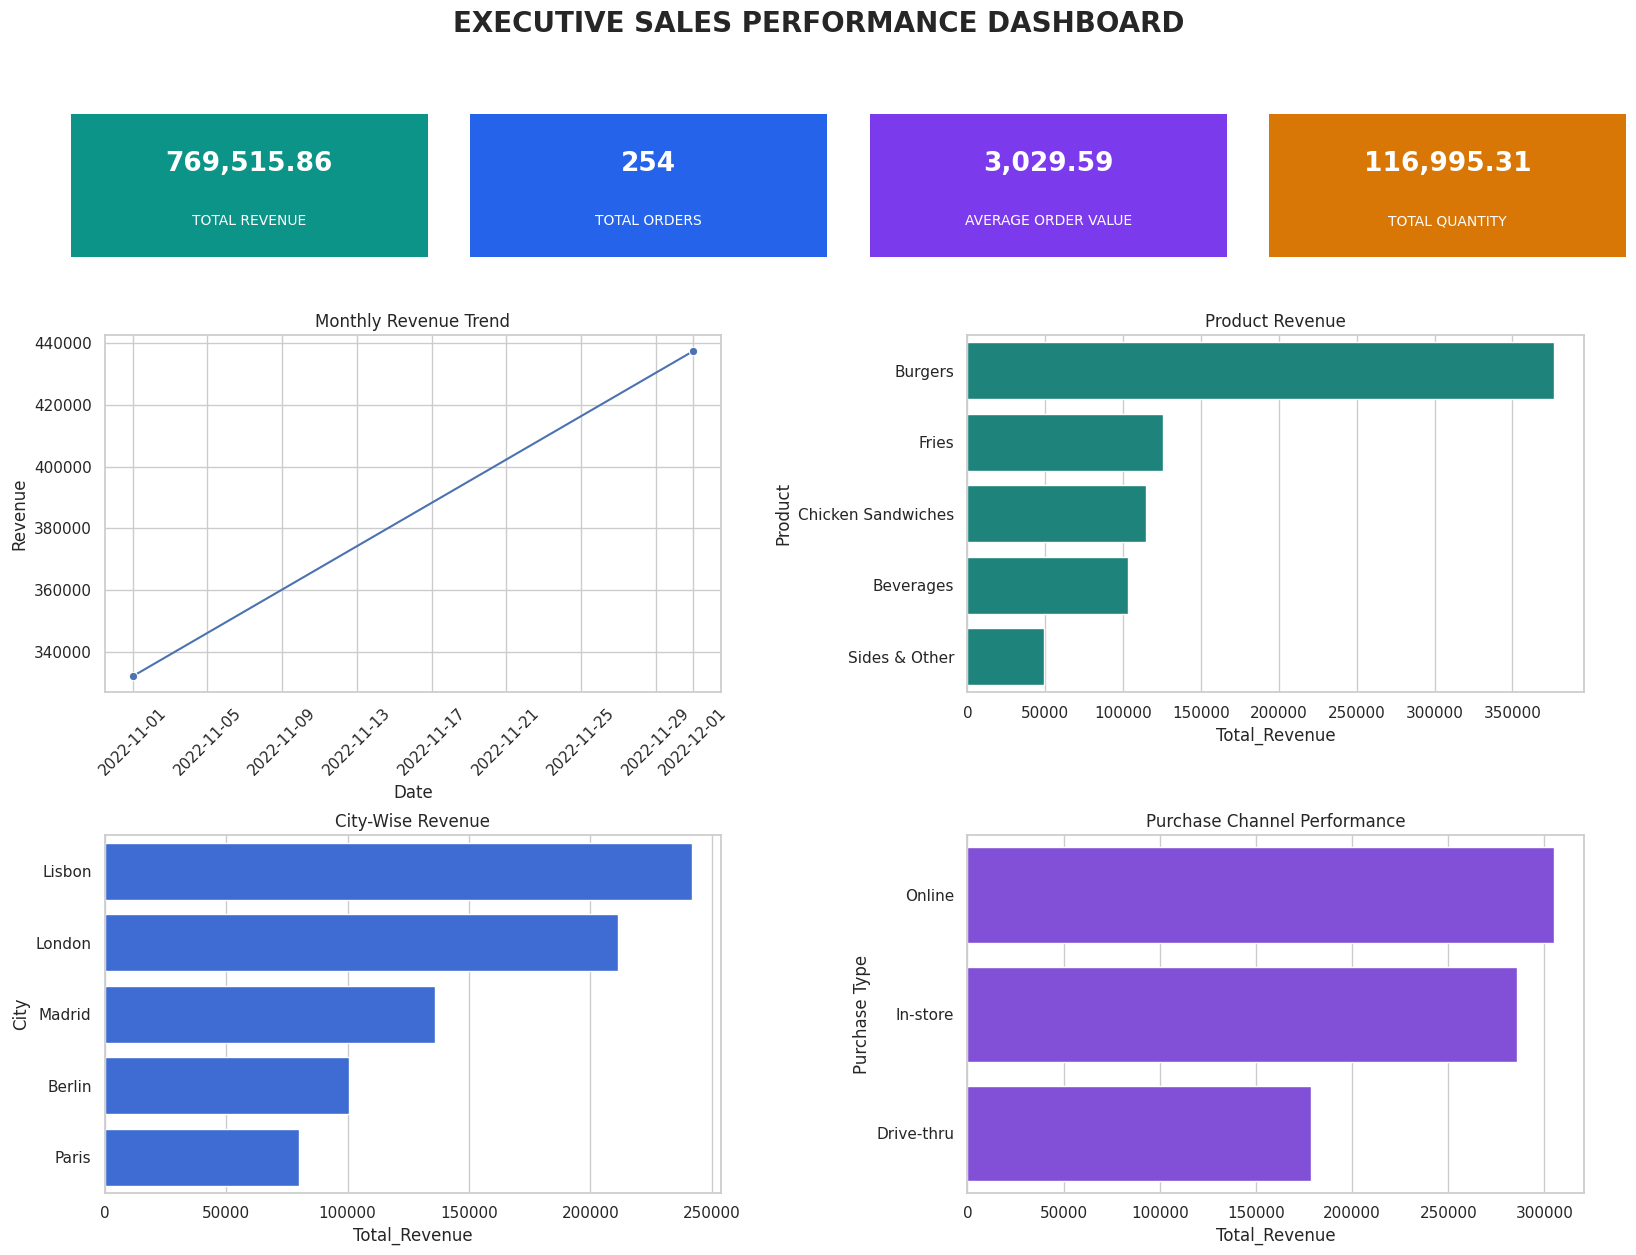

In [356]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Executive KPIs
total_revenue = customer_sales["Revenue"].sum()
total_orders = customer_sales["Order ID"].nunique()
total_quantity = customer_sales["Quantity"].sum()

aov = (
    total_revenue / total_orders
    if total_orders > 0 else 0
)

# Monthly sales
monthly = (
    customer_sales
    .dropna(subset=["Date"])
    .groupby(
        customer_sales["Date"].dt.to_period("M")
    )["Revenue"]
    .sum()
    .reset_index()
)

monthly["Date"] = (
    monthly["Date"].dt.to_timestamp()
)

# Create dashboard
fig = plt.figure(figsize=(17, 13))

fig.suptitle(
    "EXECUTIVE SALES PERFORMANCE DASHBOARD",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# KPI cards
kpis = [
    ("TOTAL REVENUE", f"{total_revenue:,.2f}"),
    ("TOTAL ORDERS", f"{total_orders:,}"),
    ("AVERAGE ORDER VALUE", f"{aov:,.2f}"),
    ("TOTAL QUANTITY", f"{total_quantity:,.2f}")
]

colors = [
    "#0d9488", "#2563eb",
    "#7c3aed", "#d97706"
]

for i, ((label, value), color) in enumerate(
    zip(kpis, colors)
):
    ax = fig.add_axes([
        0.06 + i * 0.235,
        0.79,
        0.21,
        0.11
    ])

    ax.set_facecolor(color)

    ax.text(
        0.5, 0.65, value,
        ha="center", va="center",
        fontsize=19,
        fontweight="bold",
        color="white"
    )

    ax.text(
        0.5, 0.25, label,
        ha="center", va="center",
        fontsize=10,
        color="white"
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

# Chart layout
gs = fig.add_gridspec(
    2, 2,
    left=0.08,
    right=0.95,
    bottom=0.07,
    top=0.73,
    hspace=0.4,
    wspace=0.4
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1])
]

# Monthly revenue
sns.lineplot(
    data=monthly,
    x="Date",
    y="Revenue",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Monthly Revenue Trend")
axes[0].tick_params(axis="x", rotation=45)

# Product revenue
sns.barplot(
    data=product_sales,
    x="Total_Revenue",
    y="Product",
    color="#0d9488",
    ax=axes[1]
)

axes[1].set_title("Product Revenue")

# City revenue
sns.barplot(
    data=city_sales,
    x="Total_Revenue",
    y="City",
    color="#2563eb",
    ax=axes[2]
)

axes[2].set_title("City-Wise Revenue")

# Purchase channel
sns.barplot(
    data=purchase_analysis,
    x="Total_Revenue",
    y="Purchase Type",
    color="#7c3aed",
    ax=axes[3]
)

axes[3].set_title("Purchase Channel Performance")

plt.show()

In [357]:
summary = pd.DataFrame({
    "Business KPI": [
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Top Revenue Product",
        "Top Revenue City",
        "Leading Purchase Channel"
    ],
    "Result": [
        round(total_revenue, 2),
        total_orders,
        round(aov, 2),
        product_sales.iloc[0]["Product"],
        city_sales.iloc[0]["City"],
        purchase_analysis.iloc[0]["Purchase Type"]
    ]
})

display(summary)

,Business KPI,Result
0,Total Revenue,769515.86
1,Total Orders,254
2,Average Order Value,3029.59
3,Top Revenue Product,Burgers
4,Top Revenue City,Lisbon
5,Leading Purchase Channel,Online


In [358]:
final_summary = pd.DataFrame({
    "Business Metric": [
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Total Quantity Sold",
        "Top Revenue Product",
        "Top Revenue City",
        "Leading Purchase Channel",
        "Leading Payment Method",
        "Highest Revenue Manager"
    ],
    "Result": [
        round(total_revenue, 2),
        total_orders,
        round(aov, 2),
        round(total_quantity, 2),
        product_sales.iloc[0]["Product"],
        city_sales.iloc[0]["City"],
        purchase_analysis.iloc[0]["Purchase Type"],
        payment_analysis.iloc[0]["Payment Method"],
        manager_sales.iloc[0]["Manager"]
    ]
})

display(final_summary)

,Business Metric,Result
0,Total Revenue,769515.86
1,Total Orders,254
2,Average Order Value,3029.59
3,Total Quantity Sold,116995.31
4,Top Revenue Product,Burgers
5,Top Revenue City,Lisbon
6,Leading Purchase Channel,Online
7,Leading Payment Method,Credit Card
8,Highest Revenue Manager,Joao Silva


In [359]:
product_contribution = product_sales.copy()

product_contribution["Revenue_Share_%"] = (
    product_contribution["Total_Revenue"]
    / product_contribution["Total_Revenue"].sum()
    * 100
)

product_contribution["Cumulative_Revenue_%"] = (
    product_contribution["Revenue_Share_%"].cumsum()
)

display(product_contribution.round(2))

,Product,Total_Revenue,Total_Quantity,Average_Price,Total_Orders,Revenue_Share_%,Cumulative_Revenue_%
1,Burgers,376999.81,29022.31,12.99,52,48.99,48.99
3,Fries,125674.29,32034.34,3.92,51,16.33,65.32
2,Chicken Sandwiches,114641.70,11135.92,10.32,52,14.90,80.22
0,Beverages,103200.26,34983.14,2.95,50,13.41,93.63
4,Sides & Other,48999.80,9819.60,4.99,49,6.37,100.00


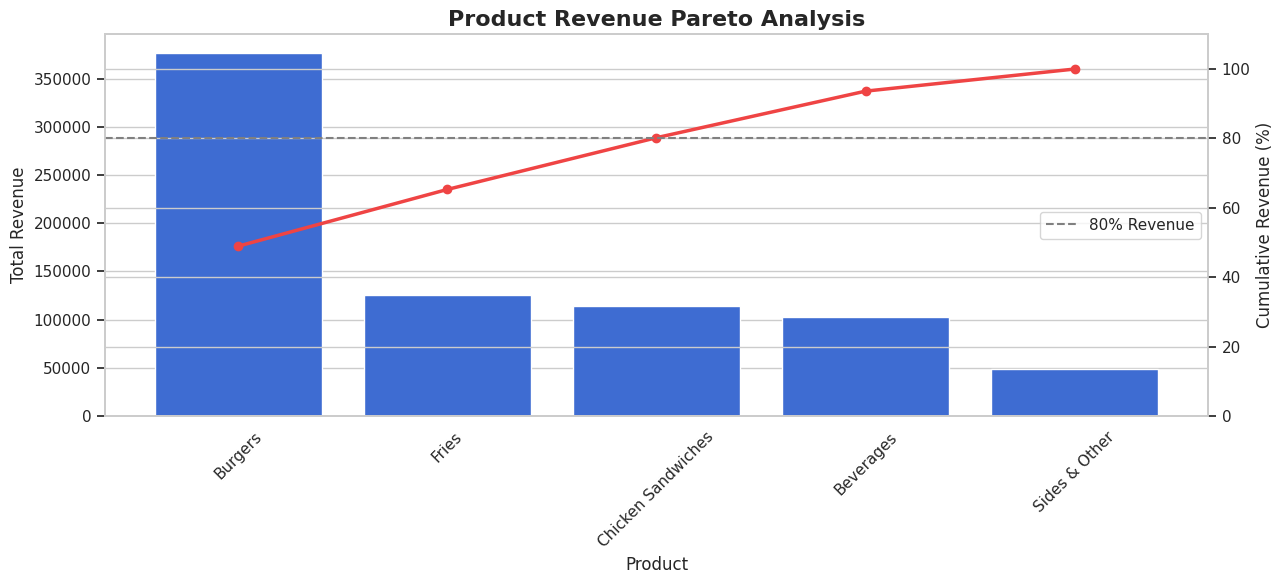

In [257]:
fig, ax1 = plt.subplots(figsize=(13, 6))

sns.barplot(
    data=product_contribution,
    x="Product",
    y="Total_Revenue",
    color="#2563eb",
    ax=ax1
)

ax1.set_xlabel("Product")
ax1.set_ylabel("Total Revenue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    range(len(product_contribution)),
    product_contribution["Cumulative_Revenue_%"],
    color="#ef4444",
    marker="o",
    linewidth=2.5
)

ax2.axhline(
    80,
    color="gray",
    linestyle="--",
    label="80% Revenue"
)

ax2.set_ylabel("Cumulative Revenue (%)")
ax2.set_ylim(0, 110)
ax2.legend(loc="center right")

plt.title(
    "Product Revenue Pareto Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [258]:
top_product = product_contribution.iloc[0]
top_city = city_sales.iloc[0]
top_channel = purchase_analysis.iloc[0]
top_payment = payment_analysis.iloc[0]

business_insights = pd.DataFrame({
    "Analysis": [
        "Product Performance",
        "Geographical Performance",
        "Purchase Behavior",
        "Payment Preferences",
        "Revenue Concentration"
    ],
    "Key Finding": [
        (
            f"{top_product['Product']} contributes "
            f"{top_product['Revenue_Share_%']:.1f}% "
            "of total revenue."
        ),
        (
            f"{top_city['City']} generates the "
            "highest total revenue."
        ),
        (
            f"{top_channel['Purchase Type']} is "
            "the leading purchase channel by revenue."
        ),
        (
            f"{top_payment['Payment Method']} "
            "generates the highest revenue."
        ),
        (
            f"The top 3 products contribute "
            f"{product_contribution.head(3)['Revenue_Share_%'].sum():.1f}% "
            "of total revenue."
        )
    ]
})

display(business_insights)

,Analysis,Key Finding
0,Product Performance,Burgers contributes 49.0% of total revenue.
1,Geographical Performance,Lisbon generates the highest total revenue.
2,Purchase Behavior,Online is the leading purchase channel by reve...
3,Payment Preferences,Credit Card generates the highest revenue.
4,Revenue Concentration,The top 3 products contribute 80.2% of total r...


In [259]:
conclusion = pd.DataFrame({
    "Executive Summary": [
        "Revenue Performance",
        "Product Performance",
        "Market Performance",
        "Customer Behavior",
        "Business Priority"
    ],
    "Conclusion": [
        f"Total recorded revenue: {total_revenue:,.2f}.",
        (
            f"{top_product['Product']} is the "
            "highest-revenue product."
        ),
        (
            f"{top_city['City']} contributes "
            "the highest city-level revenue."
        ),
        (
            f"{top_channel['Purchase Type']} "
            "leads purchase-channel revenue."
        ),
        (
            "Monitor product profitability, "
            "city-level demand and monthly growth."
        )
    ]
})

display(conclusion)

,Executive Summary,Conclusion
0,Revenue Performance,"Total recorded revenue: 769,515.86."
1,Product Performance,Burgers is the highest-revenue product.
2,Market Performance,Lisbon contributes the highest city-level reve...
3,Customer Behavior,Online leads purchase-channel revenue.
4,Business Priority,"Monitor product profitability, city-level dema..."


## ***Feature Engineering***

In [260]:
fe = df.copy()

# Clean categorical columns
cat_cols = [
    "Product", "Purchase Type",
    "Payment Method", "Manager", "City"
]

for col in cat_cols:
    fe[col] = (
        fe[col].astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Convert date
fe["Date"] = pd.to_datetime(
    fe["Date"], format="%d-%m-%Y",
    errors="coerce"
)

# Revenue
fe["Revenue"] = fe["Price"] * fe["Quantity"]

# Calendar features
fe["Year"] = fe["Date"].dt.year
fe["Month"] = fe["Date"].dt.month
fe["Month_Name"] = fe["Date"].dt.month_name()
fe["Quarter"] = fe["Date"].dt.quarter
fe["Day_of_Week"] = fe["Date"].dt.day_name()
fe["Is_Weekend"] = fe["Date"].dt.dayofweek >= 5

# Order-level revenue
fe["Order_Value"] = (
    fe.groupby("Order ID")["Revenue"]
    .transform("sum")
)

# Price segmentation
fe["Price_Segment"] = pd.cut(
    fe["Price"],
    bins=[-np.inf, 5, 10, 20, np.inf],
    labels=["Budget", "Standard", "Premium", "Luxury"]
)

display(fe.head())

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Year,Month,Month_Name,Quarter,Day_of_Week,Is_Weekend,Order_Value,Price_Segment
0,10452,2022-11-07,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London,2000.0143,2022,11,November,4,Monday,False,2000.0143,Budget
1,10453,2022-11-07,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid,2199.9920,2022,11,November,4,Monday,False,2199.9920,Budget
2,10454,2022-11-07,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon,999.9960,2022,11,November,4,Monday,False,999.9960,Budget
3,10455,2022-11-08,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin,7400.0133,2022,11,November,4,Tuesday,False,7400.0133,Premium
4,10456,2022-11-08,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin,2000.0495,2022,11,November,4,Tuesday,False,2000.0495,Standard


In [261]:
product_features = (
    fe.groupby("Product", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Average_Price=("Price", "mean")
    )
)

product_features["Revenue_Share_%"] = (
    product_features["Revenue"]
    / product_features["Revenue"].sum()
    * 100
)

display(
    product_features.sort_values(
        "Revenue", ascending=False
    ).round(2)
)

,Product,Revenue,Quantity,Average_Price,Revenue_Share_%
1,Burgers,376999.81,29022.31,12.99,48.99
3,Fries,125674.29,32034.34,3.92,16.33
2,Chicken Sandwiches,114641.70,11135.92,10.32,14.90
0,Beverages,103200.26,34983.14,2.95,13.41
4,Sides & Other,48999.80,9819.60,4.99,6.37


In [262]:
fig = px.scatter(
    fe,
    x="Quantity",
    y="Revenue",
    color="Product",
    size="Price",
    hover_data=[
        "Order ID", "City",
        "Purchase Type", "Date"
    ],
    title="Revenue vs Quantity | Product Analysis",
    labels={
        "Quantity": "Quantity",
        "Revenue": "Sales Revenue"
    },
    template="plotly_white",
    opacity=0.75
)

fig.update_layout(
    height=600,
    title_x=0.5,
    legend_title="Product"
)

fig.show()

In [263]:
fig = px.violin(
    fe,
    x="Product",
    y="Revenue",
    color="Product",
    box=True,
    points="outliers",
    title="Revenue Distribution by Product",
    template="plotly_white"
)

fig.update_layout(
    height=600,
    title_x=0.5,
    xaxis_tickangle=-30,
    showlegend=False
)

fig.show()

In [264]:
fig = px.scatter_3d(
    fe,
    x="Price",
    y="Quantity",
    z="Revenue",
    color="Product",
    size="Revenue",
    size_max=22,
    hover_data=["City", "Order ID"],
    title="3D Sales Feature Analysis",
    template="plotly_white",
    opacity=0.8
)

fig.update_layout(
    height=750,
    title_x=0.5,
    scene=dict(
        xaxis_title="Price",
        yaxis_title="Quantity",
        zaxis_title="Revenue"
    )
)

fig.show()

In [265]:
city_product = fe.pivot_table(
    index="City",
    columns="Product",
    values="Revenue",
    aggfunc="sum",
    fill_value=0,
    observed=True
)

fig = px.imshow(
    city_product,
    text_auto=".0f",
    color_continuous_scale="Viridis",
    aspect="auto",
    title="City vs Product | Revenue Heatmap",
    labels=dict(
        x="Product",
        y="City",
        color="Revenue"
    )
)

fig.update_layout(
    height=600,
    title_x=0.5
)

fig.show()

In [266]:
daily = (
    fe.groupby("Date", as_index=False)
    .agg(Revenue=("Revenue", "sum"))
    .sort_values("Date")
)

daily["Rolling_7D"] = (
    daily["Revenue"]
    .rolling(window=7, min_periods=1)
    .mean()
)

display(daily.head(10))

,Date,Revenue,Rolling_7D
0,2022-11-07,5200.0023,5200.002300
1,2022-11-08,12400.0731,8800.037700
2,2022-11-09,14200.0386,10600.038000
3,2022-11-10,13200.0426,11250.039150
4,2022-11-11,14400.0156,11880.034440
5,2022-11-12,14000.0535,12233.370950
6,2022-11-13,27674.4512,14439.239557
7,2022-11-14,17839.3445,16244.859871
8,2022-11-15,13600.0305,16416.282357
9,2022-11-16,13600.0305,16330.566914


In [267]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=daily["Date"],
        y=daily["Revenue"],
        mode="lines+markers",
        name="Daily Revenue",
        line=dict(color="#93c5fd")
    )
)

fig.add_trace(
    go.Scatter(
        x=daily["Date"],
        y=daily["Rolling_7D"],
        mode="lines",
        name="7-Day Rolling Average",
        line=dict(color="#dc2626", width=3)
    )
)

fig.update_layout(
    title="Daily Revenue & Rolling Average",
    xaxis_title="Date",
    yaxis_title="Revenue",
    template="plotly_white",
    hovermode="x unified",
    height=550
)

fig.show()

In [268]:
engineered_features = [
    "Revenue",
    "Year",
    "Month",
    "Month_Name",
    "Quarter",
    "Day_of_Week",
    "Is_Weekend",
    "Order_Value",
    "Price_Segment"
]

feature_summary = pd.DataFrame({
    "Feature": engineered_features,
    "Data Type": [
        str(fe[col].dtype)
        for col in engineered_features
    ],
    "Missing Values": [
        fe[col].isna().sum()
        for col in engineered_features
    ],
    "Unique Values": [
        fe[col].nunique()
        for col in engineered_features
    ]
})

display(feature_summary)

,Feature,Data Type,Missing Values,Unique Values
0,Revenue,float64,0,31
1,Year,int32,0,1
2,Month,int32,0,2
3,Month_Name,object,0,2
4,Quarter,int32,0,1
5,Day_of_Week,object,0,7
6,Is_Weekend,bool,0,2
7,Order_Value,float64,0,31
8,Price_Segment,category,0,4


In [269]:
# Define target
target = "Revenue"

# Select explanatory features
features = [
    "Product",
    "City",
    "Purchase Type",
    "Payment Method",
    "Manager",
    "Month",
    "Quarter",
    "Day_of_Week",
    "Is_Weekend"
]

ml_df = fe[features + [target, "Date"]].copy()

# Remove rows with missing target, date or predictors
ml_df = ml_df.dropna()

X = ml_df[features]
y = ml_df[target]

display(X.head())
display(y.to_frame().head())

,Product,City,Purchase Type,Payment Method,Manager,Month,Quarter,Day_of_Week,Is_Weekend
0,Fries,London,Online,Gift Card,Tom Jackson,11,4,Monday,False
1,Beverages,Madrid,Online,Gift Card,Pablo Perez,11,4,Monday,False
2,Sides & Other,Lisbon,In-store,Gift Card,Joao Silva,11,4,Monday,False
3,Burgers,Berlin,In-store,Credit Card,Walter Muller,11,4,Tuesday,False
4,Chicken Sandwiches,Berlin,In-store,Credit Card,Walter Muller,11,4,Tuesday,False


,Revenue
0,2000.0143
1,2199.9920
2,999.9960
3,7400.0133
4,2000.0495


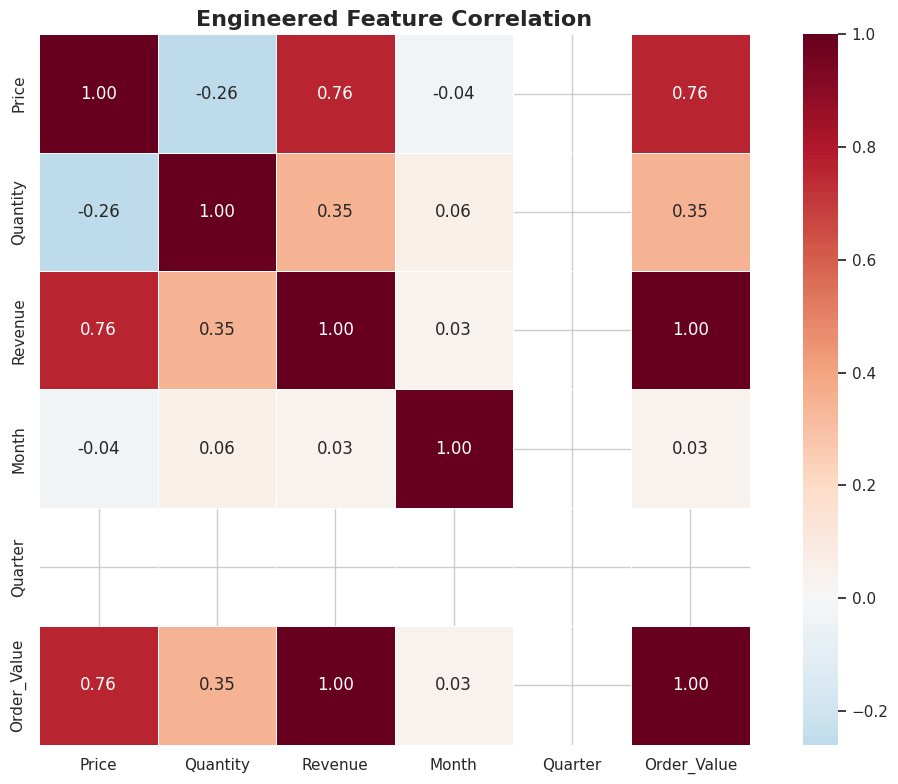

In [270]:
numeric_cols = [
    "Price",
    "Quantity",
    "Revenue",
    "Month",
    "Quarter",
    "Order_Value"
]

corr = fe[numeric_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.7
)

plt.title(
    "Engineered Feature Correlation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## ***Machine Learning***

In [271]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance

# Sort transactions chronologically
ml_df = ml_df.sort_values("Date")

# Keep dates together to avoid splitting the same day
unique_dates = ml_df["Date"].drop_duplicates().sort_values()

split_idx = int(len(unique_dates) * 0.8)

train_dates = unique_dates.iloc[:split_idx]
test_dates = unique_dates.iloc[split_idx:]

train = ml_df[ml_df["Date"].isin(train_dates)]
test = ml_df[ml_df["Date"].isin(test_dates)]

X_train = train[features]
X_test = test[features]

y_train = train[target]
y_test = test[target]

categorical_features = [
    "Product",
    "City",
    "Purchase Type",
    "Payment Method",
    "Manager",
    "Day_of_Week"
]

numeric_features = [
    "Month",
    "Quarter",
    "Is_Weekend"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            min_samples_leaf=3
        )
    )
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_test, predictions),
        np.sqrt(mean_squared_error(y_test, predictions)),
        r2_score(y_test, predictions)
    ]
})

display(metrics.round(3))

,Metric,Value
0,MAE,709.289
1,RMSE,977.515
2,R²,0.880


In [272]:
importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean,
    "Std": importance.importances_std
}).sort_values("Importance", ascending=False)

display(importance_df.round(3))

fig = px.bar(
    importance_df,
    x="Importance",
    y="Feature",
    orientation="h",
    error_x="Std",
    color="Importance",
    color_continuous_scale="Viridis",
    title="Permutation Feature Importance",
    template="plotly_white"
)

fig.update_layout(
    height=600,
    title_x=0.5,
    yaxis={
        "categoryorder": "total ascending"
    }
)

fig.show()

,Feature,Importance,Std
0,Product,1733.567,228.230
3,Payment Method,3.772,3.233
5,Month,0.000,0.000
6,Quarter,0.000,0.000
8,Is_Weekend,-0.244,1.860
7,Day_of_Week,-1.416,19.775
4,Manager,-26.951,11.175
1,City,-38.122,13.053
2,Purchase Type,-45.795,13.672


In [273]:
results = pd.DataFrame({
    "Actual Revenue": y_test.to_numpy(),
    "Predicted Revenue": predictions
})

fig = px.scatter(
    results,
    x="Actual Revenue",
    y="Predicted Revenue",
    opacity=0.7,
    title="Actual vs Predicted Revenue",
    template="plotly_white"
)

min_value = min(results.min())
max_value = max(results.max())

fig.add_shape(
    type="line",
    x0=min_value,
    y0=min_value,
    x1=max_value,
    y1=max_value,
    line=dict(
        color="red",
        dash="dash"
    )
)

fig.update_layout(
    height=600,
    title_x=0.5
)

fig.show()

In [274]:
daily_sales = (
    fe.dropna(subset=["Date", "Revenue"])
    .groupby("Date")["Revenue"]
    .sum()
    .sort_index()
    .to_frame()
)

# Create a continuous daily index
daily_sales = daily_sales.asfreq("D")

# Only use this if missing dates represent zero sales
# Otherwise, investigate missing records first.
daily_sales["Revenue"] = daily_sales["Revenue"].fillna(0)

display(daily_sales.head(10))

,Revenue
Date,
2022-11-07,5200.0023
2022-11-08,12400.0731
2022-11-09,14200.0386
2022-11-10,13200.0426
2022-11-11,14400.0156
2022-11-12,14000.0535
2022-11-13,27674.4512
2022-11-14,17839.3445
2022-11-15,13600.0305


In [275]:
forecast_df = daily_sales.copy()

# Calendar features
forecast_df["DayOfWeek"] = forecast_df.index.dayofweek
forecast_df["Month"] = forecast_df.index.month
forecast_df["Quarter"] = forecast_df.index.quarter
forecast_df["IsWeekend"] = (
    forecast_df.index.dayofweek >= 5
).astype(int)

# Historical revenue
forecast_df["Lag_1"] = (
    forecast_df["Revenue"].shift(1)
)

forecast_df["Lag_7"] = (
    forecast_df["Revenue"].shift(7)
)

forecast_df["Lag_14"] = (
    forecast_df["Revenue"].shift(14)
)

# Historical rolling statistics
past_revenue = forecast_df["Revenue"].shift(1)

forecast_df["Rolling_Mean_7"] = (
    past_revenue.rolling(7).mean()
)

forecast_df["Rolling_Mean_14"] = (
    past_revenue.rolling(14).mean()
)

forecast_df["Rolling_Std_7"] = (
    past_revenue.rolling(7).std()
)

# Remove rows without sufficient history
forecast_df = forecast_df.dropna()

display(forecast_df.head())

,Revenue,DayOfWeek,Month,Quarter,IsWeekend,Lag_1,Lag_7,Lag_14,Rolling_Mean_7,Rolling_Mean_14,Rolling_Std_7
Date,,,,,,,,,,,
2022-11-21,14000.0838,0,11,4,0,8200.0466,17839.3445,5200.0023,13662.805200,14051.022379,2830.316933
2022-11-22,13599.9918,1,11,4,0,14000.0838,13600.0305,12400.0731,13114.339386,14679.599629,2184.366297
2022-11-23,13800.0378,2,11,4,0,13599.9918,13600.0305,14200.0386,13114.333857,14765.308107,2184.364863
2022-11-24,13600.0259,3,11,4,0,13800.0378,14000.0535,13200.0426,13142.906329,14736.736621,2193.067604
2022-11-25,13399.9799,4,11,4,0,13600.0259,14400.1114,14400.0156,13085.759529,14765.306857,2172.121460


In [276]:
features = [
    "DayOfWeek",
    "Month",
    "Quarter",
    "IsWeekend",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Std_7"
]

target = "Revenue"

split = int(len(forecast_df) * 0.8)

train = forecast_df.iloc[:split]
test = forecast_df.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train = train[target]
y_test = test[target]

display(pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Observations": [len(train), len(test)],
    "Start": [train.index.min(), test.index.min()],
    "End": [train.index.max(), test.index.max()]
}))

,Dataset,Observations,Start,End
0,Training,31,2022-11-21,2022-12-21
1,Testing,8,2022-12-22,2022-12-29


In [277]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=3,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

predictions = {
    "Seasonal Naive": X_test["Lag_7"].to_numpy()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

results = []

for name, pred in predictions.items():
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_test, pred)
        ),
        "R2": r2_score(y_test, pred)
    })

comparison = pd.DataFrame(results).sort_values("MAE")

display(comparison.round(3))

,Model,MAE,RMSE,R2
2,Gradient Boosting,672.240,784.925,-2.120
1,Random Forest,1035.251,1127.490,-5.437
0,Seasonal Naive,1099.988,1212.402,-6.443


In [278]:
comparison_plot = comparison.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Error"
)

fig = px.bar(
    comparison_plot,
    x="Model",
    y="Error",
    color="Metric",
    barmode="group",
    text_auto=".2f",
    title="Forecasting Model Comparison",
    template="plotly_white"
)

fig.update_layout(
    height=550,
    title_x=0.5
)

fig.show()

In [279]:
forecast_results = pd.DataFrame(
    {"Actual": y_test},
    index=y_test.index
)

for name, pred in predictions.items():
    forecast_results[name] = pred

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=forecast_results.index,
    y=forecast_results["Actual"],
    mode="lines+markers",
    name="Actual Revenue",
    line=dict(color="#111827", width=3)
))

colors = ["#0d9488", "#6366f1", "#f59e0b"]

for (name, _), color in zip(
    predictions.items(), colors
):
    fig.add_trace(go.Scatter(
        x=forecast_results.index,
        y=forecast_results[name],
        mode="lines",
        name=name,
        line=dict(width=2, color=color)
    ))

fig.update_layout(
    title="Actual vs Predicted Daily Revenue",
    xaxis_title="Date",
    yaxis_title="Revenue",
    hovermode="x unified",
    template="plotly_white",
    height=650,
    title_x=0.5
)

fig.show()

In [280]:
fig = px.scatter_3d(
    forecast_df.reset_index(),
    x="Lag_1",
    y="Rolling_Mean_7",
    z="Revenue",
    color="Month",
    size="Revenue",
    size_max=18,
    opacity=0.75,
    hover_data=["Date"],
    title="3D Historical Sales Pattern Analysis",
    template="plotly_white"
)

fig.update_layout(
    height=750,
    title_x=0.5,
    scene=dict(
        xaxis_title="Previous Day Revenue",
        yaxis_title="7-Day Rolling Average",
        zaxis_title="Daily Revenue"
    )
)

fig.show()

In [281]:
best_model = comparison.iloc[0]["Model"]

forecast_results["Residual"] = (
    forecast_results["Actual"]
    - forecast_results[best_model]
)

fig = px.scatter(
    forecast_results.reset_index(),
    x="Date",
    y="Residual",
    color="Residual",
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
    title=f"Prediction Errors | {best_model}",
    template="plotly_white"
)

fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

fig.update_layout(
    height=550,
    title_x=0.5
)

fig.show()

In [282]:
best = comparison.iloc[0]

summary = pd.DataFrame({
    "Metric": [
        "Lowest-MAE Model",
        "Test MAE",
        "Test RMSE",
        "Test R²",
        "Training Observations",
        "Testing Observations"
    ],
    "Result": [
        best["Model"],
        round(best["MAE"], 2),
        round(best["RMSE"], 2),
        round(best["R2"], 3),
        len(train),
        len(test)
    ]
})

display(summary)

,Metric,Result
0,Lowest-MAE Model,Gradient Boosting
1,Test MAE,672.24
2,Test RMSE,784.92
3,Test R²,-2.12
4,Training Observations,31
5,Testing Observations,8


In [283]:
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Use only the training data from Step 12
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_train), start=1
):
    cv_results.append({
        "Fold": fold,
        "Training Samples": len(train_idx),
        "Validation Samples": len(val_idx),
        "Training End": X_train.index[train_idx[-1]],
        "Validation Start": X_train.index[val_idx[0]]
    })

display(pd.DataFrame(cv_results))

,Fold,Training Samples,Validation Samples,Training End,Validation Start
0,1,6,5,2022-11-26,2022-11-27
1,2,11,5,2022-12-01,2022-12-02
2,3,16,5,2022-12-06,2022-12-07
3,4,21,5,2022-12-11,2022-12-12
4,5,26,5,2022-12-16,2022-12-17


In [284]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": [0.5, 0.75, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

rf_search.fit(X_train, y_train)

display(pd.DataFrame(
    list(rf_search.best_params_.items()),
    columns=["Parameter", "Best Value"]
))

display(pd.DataFrame({
    "Metric": ["Cross-Validation MAE"],
    "Value": [-rf_search.best_score_]
}))

,Parameter,Best Value
0,n_estimators,500.00
1,min_samples_split,2.00
2,min_samples_leaf,2.00
3,max_features,0.75
4,max_depth,3.00


,Metric,Value
0,Cross-Validation MAE,969.361043


In [285]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb_params = {
    "n_estimators": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

gb_search.fit(X_train, y_train)

display(pd.DataFrame(
    list(gb_search.best_params_.items()),
    columns=["Parameter", "Best Value"]
))

,Parameter,Best Value
0,subsample,0.8
1,n_estimators,300.0
2,min_samples_leaf,1.0
3,max_depth,4.0
4,learning_rate,0.1


In [286]:
rf_cv = pd.DataFrame(rf_search.cv_results_)
gb_cv = pd.DataFrame(gb_search.cv_results_)

rf_cv["Model"] = "Random Forest"
gb_cv["Model"] = "Gradient Boosting"

cv_plot = pd.concat(
    [
        rf_cv[["Model", "mean_test_score"]],
        gb_cv[["Model", "mean_test_score"]]
    ],
    ignore_index=True
)

cv_plot["MAE"] = -cv_plot["mean_test_score"]

fig = px.box(
    cv_plot,
    x="Model",
    y="MAE",
    color="Model",
    points="all",
    title="Hyperparameter Search | Validation MAE",
    template="plotly_white"
)

fig.update_layout(
    height=550,
    title_x=0.5,
    showlegend=False
)

fig.show()

In [287]:
tuned_models = {
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned Gradient Boosting": gb_search.best_estimator_
}

# Seasonal naive baseline
tuned_predictions = {
    "Seasonal Naive": X_test["Lag_7"].to_numpy()
}

for name, model in tuned_models.items():
    tuned_predictions[name] = model.predict(X_test)

evaluation = []

for name, pred in tuned_predictions.items():
    evaluation.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_test, pred)
        ),
        "R²": r2_score(y_test, pred)
    })

evaluation_df = (
    pd.DataFrame(evaluation)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(evaluation_df.round(3))

,Model,MAE,RMSE,R²
0,Tuned Gradient Boosting,748.005,845.460,-2.619
1,Tuned Random Forest,913.320,1013.017,-4.196
2,Seasonal Naive,1099.988,1212.402,-6.443


In [288]:
plot_df = evaluation_df.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Error"
)

fig = px.bar(
    plot_df,
    x="Model",
    y="Error",
    color="Metric",
    barmode="group",
    text_auto=".2f",
    title="Tuned Forecasting Models | Error Comparison",
    template="plotly_white"
)

fig.update_layout(
    height=600,
    title_x=0.5
)

fig.show()

In [289]:
rf_3d = rf_cv.copy()

rf_3d["Trees"] = (
    rf_3d["param_n_estimators"].astype(int)
)

rf_3d["Depth"] = (
    rf_3d["param_max_depth"]
    .apply(lambda x: -1 if x is None else int(x))
)

rf_3d["MAE"] = -rf_3d["mean_test_score"]

fig = px.scatter_3d(
    rf_3d,
    x="Trees",
    y="Depth",
    z="MAE",
    color="MAE",
    size="MAE",
    hover_data=[
        "param_min_samples_split",
        "param_min_samples_leaf"
    ],
    color_continuous_scale="Viridis",
    title="3D Random Forest Hyperparameter Analysis",
    template="plotly_white"
)

fig.update_layout(
    height=750,
    title_x=0.5,
    scene=dict(
        xaxis_title="Number of Trees",
        yaxis_title="Maximum Depth (-1 = None)",
        zaxis_title="Validation MAE"
    )
)

fig.show()

In [290]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": (
        rf_search.best_estimator_.feature_importances_
    )
}).sort_values("Importance", ascending=False)

display(feature_importance.round(4))

fig = px.bar(
    feature_importance,
    x="Importance",
    y="Feature",
    orientation="h",
    color="Importance",
    color_continuous_scale="Viridis",
    title="Tuned Random Forest | Feature Importance",
    template="plotly_white"
)

fig.update_layout(
    height=600,
    title_x=0.5,
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

,Feature,Importance
4,Lag_1,0.4123
7,Rolling_Mean_7,0.1799
8,Rolling_Mean_14,0.1606
6,Lag_14,0.0866
5,Lag_7,0.0708
0,DayOfWeek,0.0524
1,Month,0.0252
9,Rolling_Std_7,0.0061
3,IsWeekend,0.0061
2,Quarter,0.0000


In [291]:
import joblib
from pathlib import Path

output_dir = Path("models")
output_dir.mkdir(exist_ok=True)

joblib.dump(
    rf_search.best_estimator_,
    output_dir / "random_forest_tuned.pkl"
)

joblib.dump(
    gb_search.best_estimator_,
    output_dir / "gradient_boosting_tuned.pkl"
)

display(pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],
    "File": [
        "random_forest_tuned.pkl",
        "gradient_boosting_tuned.pkl"
    ]
}))

,Model,File
0,Random Forest,random_forest_tuned.pkl
1,Gradient Boosting,gradient_boosting_tuned.pkl


In [292]:
# Run once if SHAP is not installed
%pip install shap plotly -q

In [293]:
import plotly.express as px
import plotly.graph_objects as go
import shap

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [294]:
# Load optimized Random Forest
best_rf = rf_search.best_estimator_

# Initialize SHAP explainer
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer(X_test)

display(
    pd.DataFrame(
        shap_values.values,
        columns=X_test.columns,
        index=X_test.index
    ).head()
)

,DayOfWeek,Month,Quarter,IsWeekend,Lag_1,Lag_7,Lag_14,Rolling_Mean_7,Rolling_Mean_14,Rolling_Std_7
Date,,,,,,,,,,
2022-12-22,25.030582,43.056620,0.0,5.039000,863.942787,56.446996,47.796663,430.890323,209.193282,13.289123
2022-12-23,10.746738,41.377594,0.0,5.039000,857.980915,128.042035,48.437417,417.140101,206.437662,14.847500
2022-12-24,5.072676,41.306311,0.0,-14.401351,863.861128,125.577751,48.100579,411.981318,203.285692,-0.623221
2022-12-25,-169.029171,40.330751,0.0,-14.401351,907.203684,122.543949,48.167843,399.473280,200.744273,-14.142288
2022-12-26,30.091836,40.769586,0.0,5.039000,851.324307,125.165517,48.307079,422.320398,210.246323,-19.768697


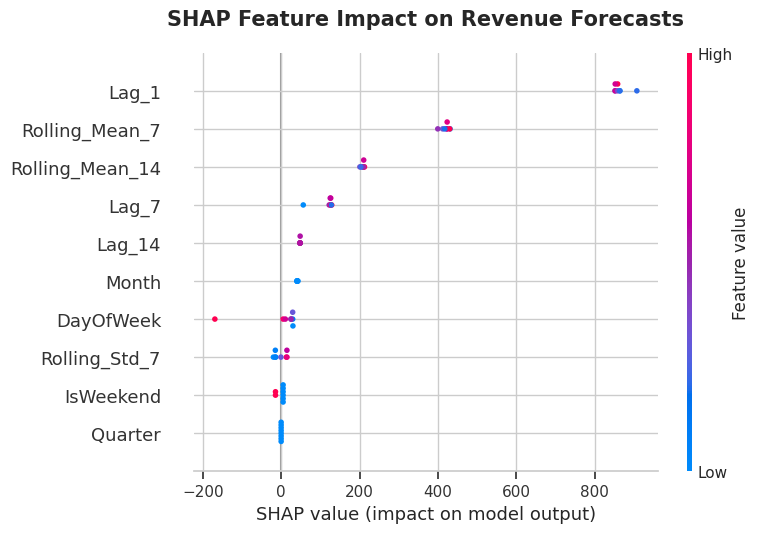

In [295]:
plt.figure(figsize=(12, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=12,
    show=False
)

plt.title(
    "SHAP Feature Impact on Revenue Forecasts",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [296]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": (
        np.abs(shap_values.values).mean(axis=0)
    )
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

display(shap_importance.round(3))

fig = px.bar(
    shap_importance,
    x="Mean_Absolute_SHAP",
    y="Feature",
    orientation="h",
    color="Mean_Absolute_SHAP",
    color_continuous_scale="Viridis",
    title="Global SHAP Feature Importance",
    template="plotly_white"
)

fig.update_layout(
    height=600,
    title_x=0.5,
    yaxis={
        "categoryorder": "total ascending"
    }
)

fig.show()

,Feature,Mean_Absolute_SHAP
4,Lag_1,863.322
7,Rolling_Mean_7,419.817
8,Rolling_Mean_14,207.956
5,Lag_7,117.479
6,Lag_14,48.307
1,Month,41.190
0,DayOfWeek,40.524
9,Rolling_Std_7,13.367
3,IsWeekend,7.380
2,Quarter,0.000


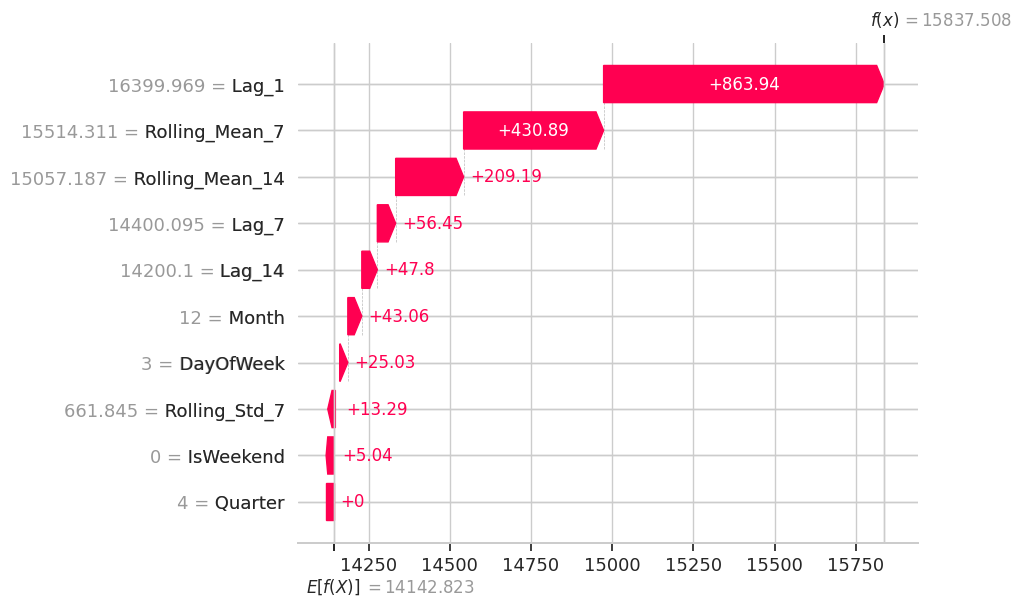

In [297]:
# Explain the first test observation
shap.plots.waterfall(
    shap_values[0],
    max_display=10
)

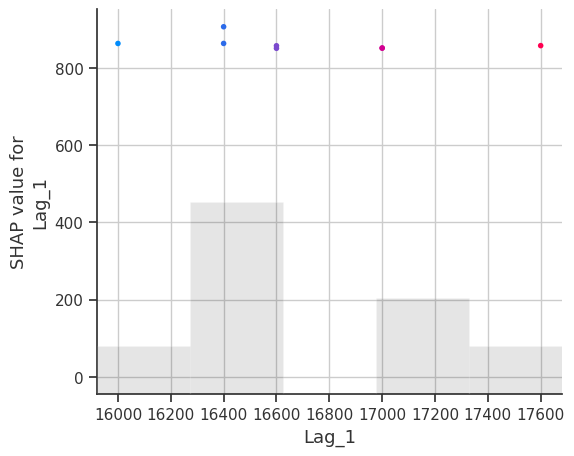

In [298]:
shap.plots.scatter(
    shap_values[:, "Lag_1"],
    color=shap_values
)

In [299]:
from sklearn.base import clone

calibration_start = int(len(X_train) * 0.8)

X_fit = X_train.iloc[:calibration_start]
y_fit = y_train.iloc[:calibration_start]

X_cal = X_train.iloc[calibration_start:]
y_cal = y_train.iloc[calibration_start:]

interval_model = clone(
    rf_search.best_estimator_
)

interval_model.fit(X_fit, y_fit)

cal_predictions = interval_model.predict(X_cal)

cal_errors = np.abs(
    y_cal.to_numpy() - cal_predictions
)

# Target nominal coverage: 90%
alpha = 0.10
n = len(cal_errors)

q_level = min(
    1.0,
    np.ceil((n + 1) * (1 - alpha)) / n
)

q = np.quantile(
    cal_errors,
    q_level,
    method="higher"
)

display(pd.DataFrame({
    "Metric": [
        "Calibration Observations",
        "Nominal Coverage",
        "Error Quantile"
    ],
    "Value": [
        n,
        "90%",
        round(q, 2)
    ]
}))

,Metric,Value
0,Calibration Observations,7
1,Nominal Coverage,90%
2,Error Quantile,2112.93


In [300]:
test_predictions = interval_model.predict(X_test)

interval_results = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": test_predictions,
    "Lower": np.maximum(test_predictions - q, 0),
    "Upper": test_predictions + q
}, index=y_test.index)

interval_results.index.name = "Date"

display(interval_results.head())

,Actual,Predicted,Lower,Upper
Date,,,,
2022-12-22,16599.9644,14439.978266,12327.046963,16552.909570
2022-12-23,16000.0218,14444.658885,12331.727581,16557.590188
2022-12-24,16399.9839,14426.062496,12313.131192,16538.993800
2022-12-25,16599.9789,14136.121463,12023.190159,16249.052767
2022-12-26,17000.0199,14421.668158,12308.736854,16534.599462


In [301]:
fig = go.Figure()

# Upper boundary
fig.add_trace(go.Scatter(
    x=interval_results.index,
    y=interval_results["Upper"],
    mode="lines",
    line=dict(width=0),
    showlegend=False,
    hoverinfo="skip"
))

# Lower boundary and shaded interval
fig.add_trace(go.Scatter(
    x=interval_results.index,
    y=interval_results["Lower"],
    mode="lines",
    fill="tonexty",
    fillcolor="rgba(13,148,136,0.20)",
    line=dict(width=0),
    name="90% Prediction Interval"
))

# Actual revenue
fig.add_trace(go.Scatter(
    x=interval_results.index,
    y=interval_results["Actual"],
    mode="lines+markers",
    name="Actual Revenue",
    line=dict(color="#2563eb", width=2)
))

# Predicted revenue
fig.add_trace(go.Scatter(
    x=interval_results.index,
    y=interval_results["Predicted"],
    mode="lines",
    name="Predicted Revenue",
    line=dict(color="#0d9488", width=3)
))

fig.update_layout(
    title="Daily Revenue Forecast with Prediction Intervals",
    xaxis_title="Date",
    yaxis_title="Revenue",
    template="plotly_white",
    hovermode="x unified",
    height=600
)

fig.show()

In [302]:
inside = (
    (interval_results["Actual"] >= interval_results["Lower"])
    &
    (interval_results["Actual"] <= interval_results["Upper"])
)

coverage = inside.mean() * 100

average_width = (
    interval_results["Upper"] -
    interval_results["Lower"]
).mean()

interval_metrics = pd.DataFrame({
    "Metric": [
        "Nominal Coverage",
        "Observed Test Coverage (%)",
        "Average Interval Width",
        "Test MAE",
        "Test RMSE",
        "Test R²"
    ],
    "Value": [
        "90%",
        round(coverage, 2),
        round(average_width, 2),
        round(mean_absolute_error(
            interval_results["Actual"],
            interval_results["Predicted"]
        ), 2),
        round(np.sqrt(mean_squared_error(
            interval_results["Actual"],
            interval_results["Predicted"]
        )), 2),
        round(r2_score(
            interval_results["Actual"],
            interval_results["Predicted"]
        ), 3)
    ]
})

display(interval_metrics)

,Metric,Value
0,Nominal Coverage,90%
1,Observed Test Coverage (%),25.0
2,Average Interval Width,4225.86
3,Test MAE,2351.81
4,Test RMSE,2393.32
5,Test R²,-28.003


In [303]:
from plotly.subplots import make_subplots

dashboard = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Actual vs Predicted Revenue",
        "Prediction Error Distribution",
        "SHAP Feature Importance",
        "Actual vs Predicted Scatter"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# Revenue trend
dashboard.add_trace(
    go.Scatter(
        x=interval_results.index,
        y=interval_results["Actual"],
        name="Actual",
        line=dict(color="#2563eb")
    ),
    row=1, col=1
)

dashboard.add_trace(
    go.Scatter(
        x=interval_results.index,
        y=interval_results["Predicted"],
        name="Predicted",
        line=dict(color="#0d9488")
    ),
    row=1, col=1
)

# Residual distribution
residuals = (
    interval_results["Actual"] -
    interval_results["Predicted"]
)

dashboard.add_trace(
    go.Histogram(
        x=residuals,
        name="Residuals",
        marker_color="#7c3aed"
    ),
    row=1, col=2
)

# SHAP importance
top_features = shap_importance.head(10)

dashboard.add_trace(
    go.Bar(
        x=top_features["Mean_Absolute_SHAP"],
        y=top_features["Feature"],
        orientation="h",
        name="SHAP Importance",
        marker_color="#0891b2"
    ),
    row=2, col=1
)

# Actual vs predicted
dashboard.add_trace(
    go.Scatter(
        x=interval_results["Actual"],
        y=interval_results["Predicted"],
        mode="markers",
        name="Predictions",
        marker=dict(
            color="#d97706",
            opacity=0.7
        )
    ),
    row=2, col=2
)

dashboard.update_layout(
    title=dict(
        text="Advanced Sales Forecasting Dashboard",
        x=0.5,
        font=dict(size=22)
    ),
    height=950,
    template="plotly_white",
    showlegend=True
)

dashboard.show()

In [304]:
import joblib
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Save interactive dashboard
dashboard.write_html(
    output_dir / "sales_forecasting_dashboard.html"
)

# Save interval forecasting model
joblib.dump(
    interval_model,
    output_dir / "interval_forecasting_model.pkl"
)

# Save prediction results
interval_results.to_csv(
    output_dir / "forecast_results.csv"
)

display(pd.DataFrame({
    "Output": [
        "Interactive Dashboard",
        "Forecasting Model",
        "Prediction Results"
    ],
    "File": [
        "sales_forecasting_dashboard.html",
        "interval_forecasting_model.pkl",
        "forecast_results.csv"
    ]
}))

,Output,File
0,Interactive Dashboard,sales_forecasting_dashboard.html
1,Forecasting Model,interval_forecasting_model.pkl
2,Prediction Results,forecast_results.csv


In [305]:
%pip install streamlit plotly joblib scikit-learn -q

In [306]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib

display({
    "Streamlit Version": st.__version__,
    "Pandas Version": pd.__version__,
    "NumPy Version": np.__version__
})

{'Streamlit Version': '1.64.0',
 'Pandas Version': '2.2.3',
 'NumPy Version': '2.1.3'}

In [307]:
%%writefile app.py

# Paste your complete Streamlit application here

Overwriting app.py


In [308]:
from pathlib import Path

Path("models").mkdir(parents=True, exist_ok=True)

In [309]:
import joblib

joblib.dump(
    rf_search.best_estimator_,
    "models/random_forest_tuned.pkl"
)

['models/random_forest_tuned.pkl']

In [310]:
from pathlib import Path

model_path = Path("models/random_forest_tuned.pkl")

display({
    "File Exists": model_path.exists(),
    "File Path": str(model_path.resolve())
})

{'File Exists': True, 'File Path': '/content/models/random_forest_tuned.pkl'}

In [311]:
import joblib

model = joblib.load("models/random_forest_tuned.pkl")

display(model)

RandomForestRegressor(max_depth=3, max_features=0.75, min_samples_leaf=2,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [312]:
from pathlib import Path
import pandas as pd

files = {
    "Trained Model": "models/random_forest_tuned.pkl",
    "Streamlit Application": "app.py",
    "Sales Dataset": "data/Sales-Data-Analysis.csv"
}

display(pd.DataFrame([
    {
        "File": name,
        "Path": path,
        "Exists": Path(path).exists()
    }
    for name, path in files.items()
]))

,File,Path,Exists
0,Trained Model,models/random_forest_tuned.pkl,True
1,Streamlit Application,app.py,True
2,Sales Dataset,data/Sales-Data-Analysis.csv,False


In [313]:
import joblib

model = joblib.load(
    "models/random_forest_tuned.pkl"
)

display(pd.DataFrame({
    "Feature": model.feature_names_in_
}))

,Feature
0,DayOfWeek
1,Month
2,Quarter
3,IsWeekend
4,Lag_1
5,Lag_7
6,Lag_14
7,Rolling_Mean_7
8,Rolling_Mean_14
9,Rolling_Std_7


In [314]:
FEATURES = [
    "DayOfWeek",
    "Month",
    "Quarter",
    "IsWeekend",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Std_7"
]

assert list(model.feature_names_in_) == FEATURES, (
    "The saved model does not match the dashboard features."
)

In [315]:
# Requires daily_sales from Step 12
history = daily_sales["Revenue"].dropna().sort_index()

if len(history) < 14:
    raise ValueError(
        "At least 14 consecutive days of sales history are required."
    )

if history.index.to_series().diff().iloc[1:].ne(
    pd.Timedelta(days=1)
).any():
    raise ValueError(
        "Historical dates must be consecutive."
    )

next_date = history.index.max() + pd.Timedelta(days=1)

input_data = pd.DataFrame([{
    "DayOfWeek": next_date.dayofweek,
    "Month": next_date.month,
    "Quarter": next_date.quarter,
    "IsWeekend": int(next_date.dayofweek >= 5),
    "Lag_1": history.iloc[-1],
    "Lag_7": history.iloc[-7],
    "Lag_14": history.iloc[-14],
    "Rolling_Mean_7": history.iloc[-7:].mean(),
    "Rolling_Mean_14": history.iloc[-14:].mean(),
    "Rolling_Std_7": history.iloc[-7:].std()
}])[FEATURES]

prediction = model.predict(input_data)[0]

display(pd.DataFrame({
    "Forecast Date": [next_date],
    "Predicted Revenue": [max(0, prediction)]
}))

,Forecast Date,Predicted Revenue
0,2022-12-30,15872.871873


In [316]:
requirements = """streamlit
pandas
numpy
scikit-learn
plotly
joblib
"""

from pathlib import Path

Path("requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

display(Path("requirements.txt").read_text())

'streamlit\npandas\nnumpy\nscikit-learn\nplotly\njoblib\n'

In [317]:
gitignore = """
__pycache__/
*.pyc
.ipynb_checkpoints/
.venv/
venv/
.env
.streamlit/secrets.toml
"""

Path(".gitignore").write_text(
    gitignore.strip() + "\n",
    encoding="utf-8"
)

81

## ***END***